# Chapter 2 — Linear Systems: Direct Methods, Iterative Methods, and Gradient-Type Methods

**Course:** Metodi Numerici — Chapter 2, *Sistemi lineari*
**Author (notes compiled by):** Matteo Guerrucci
**Format:** Theory (definitions, theorems, proofs) interleaved with Python implementations and worked exercises.

This notebook follows the structure of the course lecture notes (Gauss elimination, pivoting, $LU$
factorization, simple iterative methods, gradient-type methods) and complements them with:

* fully worked, tested Python implementations of every algorithm (first as literal translations of the
  pseudo-code, then compared against vectorized / library implementations);
* a quantitative comparison of Gaussian elimination **with** and **without** pivoting, in terms of both
  *computational cost* and *numerical stability*;
* an explicit experiment on **fill-in**: what happens when a sparse matrix is factorized with a generic
  (non structure-aware) Gaussian elimination;
* an explicit discussion of where **real analysis** (Riemann sums, the Cauchy–Schwarz inequality, the
  Banach fixed-point theorem, convexity) is the actual engine behind results that are usually stated as
  pure linear algebra;
* geometric constructions for the gradient-type methods: level curves of the quadratic functional,
  the residual as the direction of steepest descent, and a visual/numerical comparison of how different
  "training" strategies (Richardson, steepest descent, Ortomin, conjugate gradient, Jacobi,
  Gauss–Seidel) approach the solution.

A schematic summary table of every method is provided at the very end of the notebook.

## References

1. Course lecture notes: *Metodi Numerici*, Chapter 2 — *Sistemi lineari* (lectures L8–L14, handwritten
   slides on Gauss elimination, pivoting, $LU$ factorization, applications, iterative methods, gradient
   methods), and the typed lecture notes *MetNumAppunti*.
2. G. H. Golub, C. F. Van Loan, *Matrix Computations*, 4th ed., Johns Hopkins University Press, 2013.
3. L. N. Trefethen, D. Bau III, *Numerical Linear Algebra*, SIAM, 1997.
4. Y. Saad, *Iterative Methods for Sparse Linear Systems*, 2nd ed., SIAM, 2003.
5. C. T. Kelley, *Iterative Methods for Linear and Nonlinear Equations*, SIAM, 1995.
6. A. Quarteroni, R. Sacco, F. Saleri, *Numerical Mathematics*, 2nd ed., Springer, 2007.
7. W. Rudin, *Principles of Mathematical Analysis*, 3rd ed., McGraw-Hill, 1976 (for the Banach
   fixed-point theorem and elementary real analysis used throughout).

## Table of contents

- [Part 0 — Preliminaries: norms, condition number, and a fixed-point theorem](#part0)
- [2.1 Triangular systems](#s21)
- [2.2 Gaussian elimination](#s22)
  - [2.2.1 Pivoting: necessity, stability, and cost](#s221)
  - [2.2.2 Sparse matrices and the fill-in phenomenon](#s222)
- [2.3 $LU$ factorization](#s23)
- [2.4 Applications of $LU$](#s24)
- [2.5 Iterative methods](#s25)
- [2.6 Gradient-type methods](#s26)
- [2.7 Exercises](#s27)
- [Summary table](#summary)

In [1]:
import numpy as np
import scipy.linalg as sla
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
import time

np.set_printoptions(precision=6, suppress=True)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
rng = np.random.default_rng(2026)

<a id="part0"></a>
## Part 0 — Preliminaries: norms, condition number, and a fixed-point theorem

Everything in this chapter mixes two languages: **linear algebra** (matrices, eigenvalues, invertibility)
and **real analysis** (limits of sequences, contractions, convexity). We fix notation for both.

**Definition 0.1 (Vector and induced matrix norms).**
A norm on $\mathbb{R}^n$ is a map $\|\cdot\|:\mathbb{R}^n\to\mathbb{R}$ satisfying positivity,
homogeneity, and the triangle inequality. The three norms used throughout are

$$\|x\|_1=\sum_{i=1}^n|x_i|,\qquad \|x\|_2=\Big(\sum_{i=1}^n x_i^2\Big)^{1/2},\qquad \|x\|_\infty=\max_i|x_i|.$$

Every norm on $\mathbb{R}^n$ induces a matrix norm $\|A\|=\sup_{x\neq0}\|Ax\|/\|x\|$; explicitly

$$\|A\|_1=\max_j\sum_i|a_{ij}| \quad(\text{max column sum}),\qquad
\|A\|_\infty=\max_i\sum_j|a_{ij}| \quad(\text{max row sum}).$$

**Definition 0.2 (Condition number).** For $A$ invertible, $\kappa(A)=\|A\|\,\|A^{-1}\|\ge 1$. If $A$ is
symmetric, $\kappa_2(A)=\lambda_{\max}(A)/\lambda_{\min}(A)$ in absolute value. $\kappa(A)$ measures how
much relative errors in $b$ (or rounding errors in the algorithm) can be amplified in the computed
solution $x$; it will reappear as *the* quantity controlling the speed of every iterative method below.

**Fact 0.3 (Spectral theorem).** If $A\in\mathbb{R}^{n\times n}$ is symmetric, all its eigenvalues are
real and $A$ has an orthonormal basis of eigenvectors. If moreover $A$ is symmetric positive definite
(SPD), i.e. $(x,Ax)>0$ for every $x\neq0$, all eigenvalues are strictly positive. This single algebraic
fact is what makes the quadratic functional of §2.6 convex, and hence turns a linear system into an
honest minimization problem.

**Theorem 0.4 (Banach fixed-point theorem).** Let $(X,d)$ be a complete metric space and
$\Phi:X\to X$ a contraction, i.e. there is $\rho\in[0,1)$ with $d(\Phi(x),\Phi(y))\le\rho\, d(x,y)$ for
all $x,y\in X$. Then $\Phi$ has a unique fixed point $x^\*$, and for **any** starting point $x^{(0)}$ the
sequence $x^{(k+1)}=\Phi(x^{(k)})$ converges to $x^\*$ with $d(x^{(k)},x^\*)\le \rho^k d(x^{(0)},x^\*)$.

This is a **real-analysis** statement (it holds in any complete metric space, no linear structure
required). In §2.5 every "simple iterative method" (Jacobi, Gauss–Seidel, Richardson) is exactly an
affine map $\Phi(x)=Bx+c$ on $\mathbb{R}^n$ (complete under any norm), and its convergence is *nothing
but* Banach's theorem applied with $\rho=\|B\|$. Linear algebra supplies the map $B$; real analysis
supplies the guarantee that iterating it converges.

<a id="s21"></a>
## 2.1 Triangular systems

Throughout, $A\in\mathbb{R}^{n\times n}$ is invertible and $b\in\mathbb{R}^n$; we seek $x$ such that
$Ax=b$.

**Definition 2.1.** $A$ is *lower triangular* if $a_{ij}=0$ for $j>i$, *upper triangular* if $a_{ij}=0$
for $i>j$.

**Proposition 2.2.** A triangular matrix is invertible if and only if $a_{ii}\neq0$ for every $i$, and
in that case $\det A=\prod_{i=1}^n a_{ii}$.

*Proof.* Expand the determinant along the first column (lower triangular case): the only surviving
cofactor is the one multiplying $a_{11}$, and induction on the trailing $(n-1)\times(n-1)$ block gives
$\det A = \prod a_{ii}$. Since $\det A\neq0 \iff A$ invertible, the claim follows. $\blacksquare$

If $A$ is lower triangular, the system unrolls one equation at a time:
$$a_{11}x_1=b_1 \;\Rightarrow\; x_1=\frac{b_1}{a_{11}}, \qquad
a_{i1}x_1+\dots+a_{ii}x_i=b_i \;\Rightarrow\; x_i=\frac{1}{a_{ii}}\Big(b_i-\sum_{j=1}^{i-1}a_{ij}x_j\Big).$$
This is **forward substitution**. Symmetrically, an upper triangular system is solved by **back
substitution**, starting from $x_n=b_n/a_{nn}$ and going backwards:
$$x_i=\frac{1}{a_{ii}}\Big(b_i-\sum_{j=i+1}^{n}a_{ij}x_j\Big),\qquad i=n-1,\dots,1.$$

In [2]:
def forward_substitution(L, b):
    '''Solve L x = b for lower-triangular L, exactly following the pseudo-code.'''
    n = len(b)
    x = np.zeros(n)
    x[0] = b[0] / L[0, 0]
    for i in range(1, n):
        s = 0.0
        for j in range(i):
            s += L[i, j] * x[j]
        x[i] = (b[i] - s) / L[i, i]
    return x


def back_substitution(U, b):
    '''Solve U x = b for upper-triangular U, exactly following the pseudo-code.'''
    n = len(b)
    x = np.zeros(n)
    x[-1] = b[-1] / U[-1, -1]
    for i in range(n - 2, -1, -1):
        s = 0.0
        for j in range(i + 1, n):
            s += U[i, j] * x[j]
        x[i] = (b[i] - s) / U[i, i]
    return x

In [3]:
# Sanity check against a random triangular system
n = 6
L = np.tril(rng.uniform(1, 2, size=(n, n)))
b = rng.uniform(-1, 1, size=n)
x = forward_substitution(L, b)
print("forward substitution residual ||Lx-b|| =", np.linalg.norm(L @ x - b))
print("matches np.linalg.solve:", np.allclose(x, np.linalg.solve(L, b)))

U = np.triu(rng.uniform(1, 2, size=(n, n)))
x2 = back_substitution(U, b)
print("back substitution residual ||Ux-b|| =", np.linalg.norm(U @ x2 - b))

forward substitution residual ||Lx-b|| = 2.498001805406602e-16
matches np.linalg.solve: True
back substitution residual ||Ux-b|| = 1.6653345369377348e-16


**Complexity.** At step $i$ we perform $i-1$ multiplications and $i-1$ additions, plus one division. So
the total number of flops for forward substitution is
$$\sum_{i=1}^{n}(2(i-1)+1) = n^2 = O(n^2).$$
Both substitutions cost $O(n^2)$: two orders of magnitude cheaper than the $O(n^3)$ factorization that
produces the triangular system in the first place (§2.2–2.3). This is precisely *why*, given many
right-hand sides $b$, one factorizes $A$ once and reuses the (cheap) triangular solves — see §2.4.

**Remark (never invert to solve).** It is always preferable to reduce a generic system to a triangular
one (Gauss/$LU$) and use substitution, rather than forming $A^{-1}$ explicitly and computing
$A^{-1}b$: forming the inverse costs $\sim\frac{4}{3}n^3$ against $\sim\frac13 n^3$ for a factorization
(§2.4.2), and it is also numerically less accurate. In MATLAB/NumPy terms: prefer `np.linalg.solve(A,
b)` (equivalent to `A\b`) over `np.linalg.inv(A) @ b`. We verify this quantitatively in §2.4.3.

<a id="s22"></a>
## 2.2 Gaussian elimination

The idea: transform $Ax=b$ into an equivalent triangular system $Ux=\tilde b$ using row operations that
do not change the solution set, then solve by back substitution.

Denote by $A^{(0)}=A$ and by $A^{(k)}$ the matrix obtained after $k$ elimination stages. At stage $k$ we
eliminate the entries below the pivot $a_{kk}^{(k-1)}$ in column $k$ using the **multipliers**
$$m_{ik}=\frac{a_{ik}^{(k-1)}}{a_{kk}^{(k-1)}},\qquad i=k+1,\dots,n,$$
and update
$$a_{ij}^{(k)} = a_{ij}^{(k-1)} - m_{ik}\,a_{kj}^{(k-1)},\qquad b_i^{(k)}=b_i^{(k-1)}-m_{ik}b_k^{(k-1)}.$$

**Proposition 2.3 (matrix form).** Each stage is left-multiplication by an elementary matrix $M_k$
(identity, with $-m_{ik}$ placed below the diagonal in column $k$):
$$A^{(k)}=M_kA^{(k-1)},\qquad M_k=I-\sum_{i>k}m_{ik}\,e_ie_k^T.$$
After $n-1$ stages, $U:=A^{(n-1)}=M_{n-1}\cdots M_1A$ is upper triangular, and
$\tilde b = M_{n-1}\cdots M_1 b$. Since every $M_k$ is invertible ($\det M_k=1$), the system $Ux=\tilde b$
is equivalent to $Ax=b$.

In [4]:
def gauss_elimination(A, b):
    '''Forward elimination A x = b -> U x = btilde. Overwrites nothing (works on copies),
    following Algorithm 3 of the lecture notes literally (no pivoting).'''
    A = A.astype(float).copy()
    b = b.astype(float).copy()
    n = len(b)
    for k in range(n - 1):
        if A[k, k] == 0.0:
            raise ZeroDivisionError(f"zero pivot at stage k={k}: pivoting is required")
        for i in range(k + 1, n):
            m = A[i, k] / A[k, k]
            for j in range(k + 1, n):
                A[i, j] -= m * A[k, j]
            A[i, k] = 0.0
            b[i] -= m * b[k]
    return A, b


def solve_gauss(A, b):
    U, btilde = gauss_elimination(A, b)
    return back_substitution(U, btilde)

In [5]:
# The textbook 3x3 example (same system used in the course's first exercise notebook)
A = np.array([[2., 1., -1.],
              [-3., -1., 2.],
              [-2., 1., 2.]])
b = np.array([8., -11., -3.])

x = solve_gauss(A, b)
print("computed solution x =", x)
print("expected solution   =", [2., 3., -1.])
print("residual ||Ax-b||   =", np.linalg.norm(A @ x - b))

computed solution x = [ 2.  3. -1.]
expected solution   = [2.0, 3.0, -1.0]
residual ||Ax-b||   = 0.0


**Cost of Gaussian elimination — a Riemann-sum argument.** At stage $k$ we update the trailing
$(n-k)\times(n-k)$ submatrix, i.e. $(n-k)^2$ entries, each with one multiplication and one subtraction.
Summing over all stages,
$$\text{Cost} = \sum_{k=1}^{n-1}(n-k)^2 = \sum_{j=1}^{n-1}j^2=\frac{(n-1)n(2n-1)}{6}.$$
This is a genuine piece of **real analysis**: the discrete sum is a (left) Riemann sum for
$\int_0^n x^2\,dx = n^3/3$, so for large $n$
$$\text{Cost} \;\approx\; \int_0^n x^2\,dx = \frac{n^3}{3} = O(n^3).$$
Geometrically this is the "pyramid of unit cubes" picture from the lectures: a stack of decreasing
square layers of side $n-k$, whose volume is exactly a pyramid with a right-triangular base of legs $n$
and height $n$. We check the asymptotics numerically below.

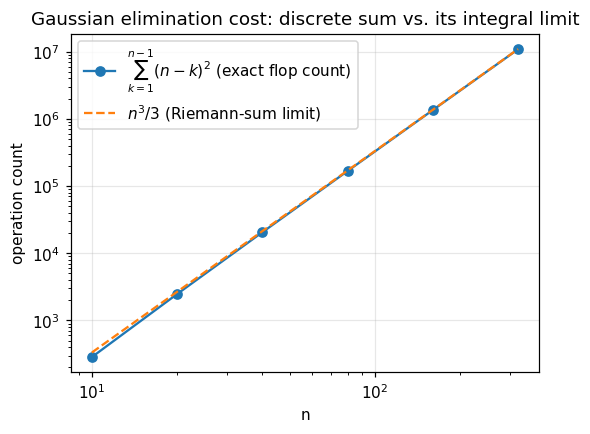

ratio (exact sum) / (n^3/3) as n grows: [0.855  0.9262 0.9628 0.9813 0.9906 0.9953]


In [6]:
ns = np.array([10, 20, 40, 80, 160, 320])
exact_sum = np.array([sum((n - k) ** 2 for k in range(1, n)) for n in ns])
cubic_term = ns ** 3 / 3

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.loglog(ns, exact_sum, "o-", label=r"$\sum_{k=1}^{n-1}(n-k)^2$ (exact flop count)")
ax.loglog(ns, cubic_term, "--", label=r"$n^3/3$ (Riemann-sum limit)")
ax.set_xlabel("n"); ax.set_ylabel("operation count"); ax.legend()
ax.set_title("Gaussian elimination cost: discrete sum vs. its integral limit")
plt.show()

print("ratio (exact sum) / (n^3/3) as n grows:", (exact_sum / cubic_term).round(4))

The ratio tends to $1$: the discrete operation count and the continuous $n^3/3$ estimate agree
asymptotically, exactly as a Riemann sum converges to its integral. Back substitution only adds $O(n^2)$,
so the **total cost of solving one system by Gaussian elimination is $O(n^3)$**, dominated by the
elimination phase.

<a id="s221"></a>
### 2.2.1 Pivoting: necessity, stability, and cost

Two logically distinct issues motivate pivoting.

**1. Necessity.** If $a_{kk}^{(k-1)}=0$, the multiplier $m_{ik}$ is undefined: the algorithm breaks down
even though $A$ may be perfectly invertible. Since $A^{(k-1)}$ is invertible, column $k$ of the trailing
block cannot be entirely zero, so some $a_{ik}^{(k-1)}\neq 0$, $i\ge k$, exists; swapping row $k$ with row
$i$ repairs the algorithm.

**2. Stability.** Even when $a_{kk}^{(k-1)}\neq0$, if it is *small* relative to the entries below it, the
multiplier $m_{ik}=a_{ik}^{(k-1)}/a_{kk}^{(k-1)}$ is *large*, and it amplifies whatever rounding error is
already present in floating-point arithmetic. This is conceptually close to (but distinct from) the
catastrophic cancellation discussed in Chapter 1: here the danger is an amplifying *division* by a
small number, not a subtraction of nearby quantities.

**Partial pivoting.** At stage $k$, before eliminating, choose
$$\ell=\arg\max_{k\le i\le n}\big|a_{ik}^{(k-1)}\big|,$$
and swap row $k$ with row $\ell$. Formally this is left-multiplication by a **permutation matrix**
$P^{(i,\ell)}$ (the identity with rows $i,\ell$ swapped), which satisfies
$$\big(P^{(i,\ell)}\big)^2=I \;\Longrightarrow\; \big(P^{(i,\ell)}\big)^{-1}=P^{(i,\ell)},\qquad
\det P^{(i,\ell)}=-1.$$

**Theorem 2.4.** With partial pivoting, every multiplier satisfies $|m_{ik}|\le 1$.

*Proof.* By construction $|a_{kk}^{(k-1)}|=\max_{i\ge k}|a_{ik}^{(k-1)}|\ge|a_{ik}^{(k-1)}|$ for every
$i\ge k$, so $|m_{ik}|=|a_{ik}^{(k-1)}|/|a_{kk}^{(k-1)}|\le1$. $\blacksquare$

Bounded multipliers keep the growth factor of the entries under control, which is the standard argument
for the backward stability of partial pivoting (Golub & Van Loan, Ch. 3).

In [7]:
def gauss_pivot(A, b):
    '''Gaussian elimination with partial (column) pivoting.
    Returns U, btilde and the permutation-tracking vector p (p[k]=k means no swap at stage k).'''
    A = A.astype(float).copy()
    b = b.astype(float).copy()
    n = len(b)
    p = np.arange(n)
    for k in range(n - 1):
        ell = k + np.argmax(np.abs(A[k:, k]))
        if A[ell, k] == 0.0:
            raise np.linalg.LinAlgError("matrix is singular: no nonzero pivot available")
        if ell != k:
            A[[k, ell], :] = A[[ell, k], :]
            b[k], b[ell] = b[ell], b[k]
            p[k] = ell
        for i in range(k + 1, n):
            m = A[i, k] / A[k, k]
            A[i, k:] -= m * A[k, k:]
            b[i] -= m * b[k]
    return A, b, p


def solve_gauss_pivot(A, b):
    U, btilde, _ = gauss_pivot(A, b)
    return back_substitution(U, btilde)

#### Numerical experiment: does pivoting matter?

We reproduce the classical example from the lectures: $A=\begin{pmatrix}\varepsilon&1\\1&1\end{pmatrix}$,
$b=\begin{pmatrix}1\\0\end{pmatrix}$, whose *exact* solution is $x=1/(\varepsilon-1)\to-1$,
$y=1/(1-\varepsilon)\to1$ as $\varepsilon\to0$. Gaussian elimination **without** pivoting uses the
multiplier $m_{21}=1/\varepsilon$, which is huge; the update $1-1/\varepsilon\to -1/\varepsilon$ rounds
catastrophically in floating point. With pivoting, the multiplier is $\varepsilon$ itself (small), and
the computed solution stays accurate.

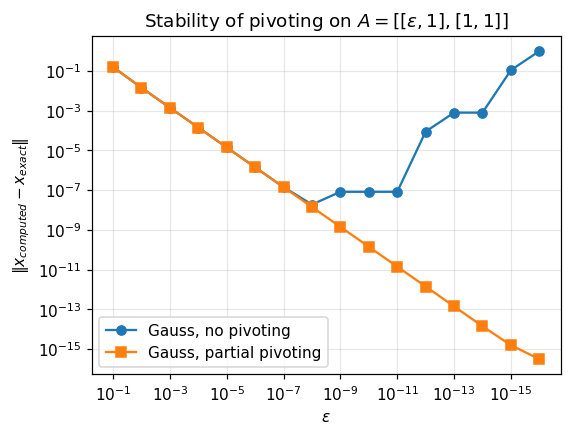

       eps |   error no pivot |    error pivot
   1.0e-01 |        1.571e-01 |      1.571e-01
   1.0e-04 |        1.414e-04 |      1.414e-04
   1.0e-07 |        1.418e-07 |      1.414e-07
   1.0e-10 |        8.274e-08 |      1.414e-10
   1.0e-13 |        7.993e-04 |      1.416e-13
   1.0e-16 |        1.000e+00 |      3.140e-16


In [8]:
def solve_no_pivot_2x2(eps):
    A = np.array([[eps, 1.0], [1.0, 1.0]])
    b = np.array([1.0, 0.0])
    return solve_gauss(A, b)

def solve_pivot_2x2(eps):
    A = np.array([[eps, 1.0], [1.0, 1.0]])
    b = np.array([1.0, 0.0])
    return solve_gauss_pivot(A, b)

exact = np.array([-1.0, 1.0])
eps_values = 10.0 ** (-np.arange(1, 17, dtype=float))

err_no_pivot = []
err_pivot = []
for eps in eps_values:
    err_no_pivot.append(np.linalg.norm(solve_no_pivot_2x2(eps) - exact))
    err_pivot.append(np.linalg.norm(solve_pivot_2x2(eps) - exact))

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.loglog(eps_values, err_no_pivot, "o-", label="Gauss, no pivoting")
ax.loglog(eps_values, err_pivot, "s-", label="Gauss, partial pivoting")
ax.set_xlabel(r"$\varepsilon$"); ax.set_ylabel(r"$\|x_{computed}-x_{exact}\|$")
ax.invert_xaxis()
ax.set_title("Stability of pivoting on " + r"$A=[[\varepsilon,1],[1,1]]$")
ax.legend()
plt.show()

print(f"{'eps':>10} | {'error no pivot':>16} | {'error pivot':>14}")
for eps, e1, e2 in list(zip(eps_values, err_no_pivot, err_pivot))[::3]:
    print(f"{eps:10.1e} | {e1:16.3e} | {e2:14.3e}")

As $\varepsilon\to0$, the non-pivoted solution error grows to $O(1)$ — the computed answer becomes
**completely wrong** — while pivoting keeps the error at the floating-point round-off level
($\sim10^{-16}$) for every $\varepsilon$. This confirms Theorem 2.4 experimentally: bounded multipliers
$\Rightarrow$ bounded error amplification.

#### Cost of pivoting

Searching for the pivot at stage $k$ costs $O(n-k)$ comparisons, so over the whole elimination the extra
cost is $\sum_{k=1}^{n-1}(n-k)=O(n^2)$ — **asymptotically negligible** next to the $O(n^3)$ elimination
cost. We verify this with a timing benchmark: pivoted and non-pivoted elimination should scale with the
*same* cubic exponent, with pivoting only slightly slower in absolute terms.

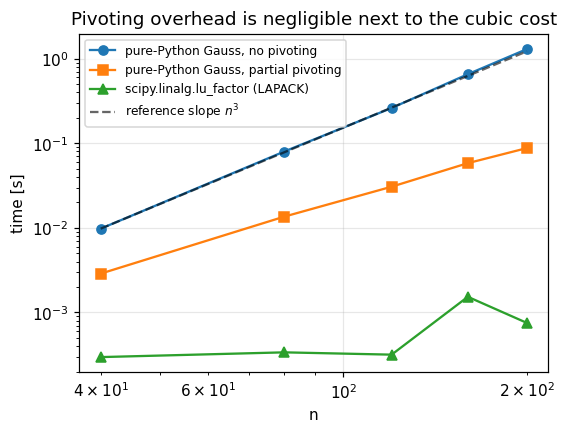

In [9]:
sizes = [40, 80, 120, 160, 200]
t_nopivot, t_pivot, t_scipy = [], [], []
for n in sizes:
    Atest = rng.uniform(-1, 1, size=(n, n)) + n * np.eye(n)  # diagonally dominant: pivot-free path is safe
    btest = rng.uniform(-1, 1, size=n)

    t0 = time.perf_counter(); solve_gauss(Atest, btest); t_nopivot.append(time.perf_counter() - t0)
    t0 = time.perf_counter(); solve_gauss_pivot(Atest, btest); t_pivot.append(time.perf_counter() - t0)
    t0 = time.perf_counter(); sla.lu_factor(Atest); t_scipy.append(time.perf_counter() - t0)

sizes_arr = np.array(sizes, dtype=float)
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.loglog(sizes_arr, t_nopivot, "o-", label="pure-Python Gauss, no pivoting")
ax.loglog(sizes_arr, t_pivot, "s-", label="pure-Python Gauss, partial pivoting")
ax.loglog(sizes_arr, t_scipy, "^-", label="scipy.linalg.lu_factor (LAPACK)")
ax.loglog(sizes_arr, t_nopivot[0] * (sizes_arr / sizes_arr[0]) ** 3, "k--", alpha=0.6, label=r"reference slope $n^3$")
ax.set_xlabel("n"); ax.set_ylabel("time [s]"); ax.legend(fontsize=8)
ax.set_title("Pivoting overhead is negligible next to the cubic cost")
plt.show()

The pivoted and non-pivoted curves are essentially parallel to the $n^3$ reference line and to each
other: pivoting changes the *constant*, not the *exponent*, of the cost. Given that it is essentially
free and removes a catastrophic failure mode, **partial pivoting should always be used** — this is why
`scipy.linalg.lu_factor` / MATLAB's backslash use it by default. (The large gap to the LAPACK curve is
simply the cost of our explicit Python `for` loops versus compiled, blocked linear-algebra kernels — a
constant-factor effect, not a change in asymptotic order.)

<a id="s222"></a>
### 2.2.2 Sparse matrices and the fill-in phenomenon

**Definition 2.5.** $A$ is *sparse* if the number of nonzero entries is $O(n)$ (or $O(n\log n)$), rather
than $O(n^2)$. Large sparse matrices are ubiquitous in the discretization of differential equations,
graphs, and networks; storing and operating on only the nonzero entries is essential when $n$ is large
(e.g. $n\sim10^6$, where a dense array would need terabytes of memory).

**The problem: fill-in.** Gaussian elimination replaces $a_{ij}$ with $a_{ij}-m_{ik}a_{kj}$. If
$a_{ij}=0$ but $a_{ik}\neq0$ and $a_{kj}\neq0$, the entry becomes **nonzero** — a *fill-in*. Generic
Gaussian elimination on a sparse matrix can turn most of its zero entries into nonzero ones, destroying
the sparsity structure and, with it, every memory/speed advantage of the sparse representation. Whether
fill-in happens depends entirely on the sparsity **pattern**, not merely on the number of nonzeros.

We illustrate both extremes: a matrix where fill-in is *absent* (banded, e.g. tridiagonal) and one where
it is *catastrophic* (the 2-D discrete Laplacian, a genuinely sparse SPD matrix that will reappear in
§2.6 and §2.7 as the standard test case for gradient-type methods).

In [10]:
def tridiag_Tn(n):
    '''The tridiagonal SPD matrix T_n = tridiag(-1, 2, -1), Exercise 2.7.5 of the notes.'''
    return (np.diag(2.0 * np.ones(n))
            + np.diag(-1.0 * np.ones(n - 1), 1)
            + np.diag(-1.0 * np.ones(n - 1), -1))


def laplacian_2d(m):
    '''Sparse SPD 2-D discrete Laplacian on an m x m grid (5-point stencil), n = m**2 unknowns.
    This is the natural, library-independent analogue of MATLAB's gallery('poisson', m).'''
    I = sp.identity(m, format="csr")
    e = np.ones(m)
    T = sp.diags([-e[:-1], 2 * e, -e[:-1]], offsets=[-1, 0, 1], format="csr")
    return sp.kron(I, T) + sp.kron(T, I)


n_band = 12
T = tridiag_Tn(n_band)
U_band, _ = gauss_elimination(T.copy(), np.zeros(n_band))
print("nonzeros in T_n           :", np.count_nonzero(T))
print("nonzeros in U (after Gauss):", np.count_nonzero(np.triu(U_band)))
print("-> a tridiagonal matrix has NO fill-in: L and U stay bidiagonal.")

nonzeros in T_n           : 34
nonzeros in U (after Gauss): 23
-> a tridiagonal matrix has NO fill-in: L and U stay bidiagonal.


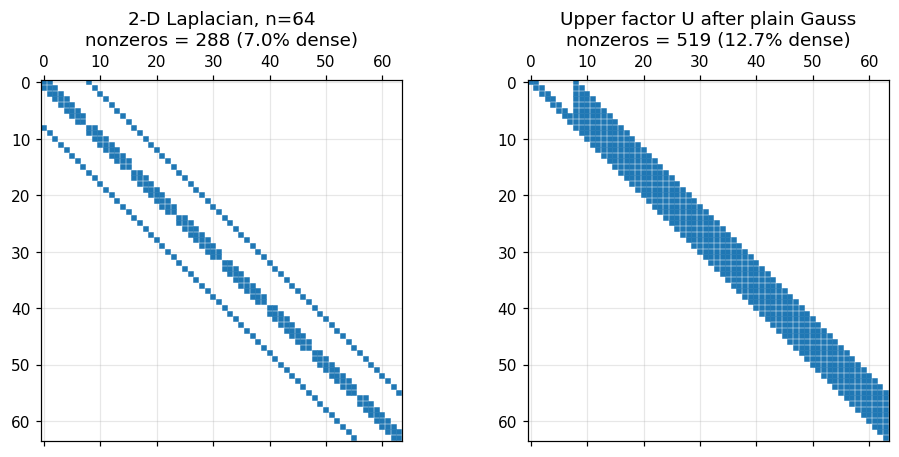

fill-in factor: 1.80x more nonzeros in U than in A


In [11]:
m = 8  # grid is m x m, matrix size n = m**2 = 64
Lap = laplacian_2d(m)
n = Lap.shape[0]
A_dense = Lap.toarray()

U_dense, _ = gauss_elimination(A_dense.copy(), np.zeros(n))
nnz_before = np.count_nonzero(A_dense)
nnz_after = np.count_nonzero(np.triu(U_dense))

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
axes[0].spy(A_dense, markersize=3)
axes[0].set_title(f"2-D Laplacian, n={n}\nnonzeros = {nnz_before} ({100*nnz_before/n**2:.1f}% dense)")
axes[1].spy(U_dense, markersize=3)
axes[1].set_title(f"Upper factor U after plain Gauss\nnonzeros = {nnz_after} ({100*nnz_after/n**2:.1f}% dense)")
plt.tight_layout(); plt.show()

print(f"fill-in factor: {nnz_after / nnz_before:.2f}x more nonzeros in U than in A")

The band structure of $T_n$ is preserved exactly (no fill-in: eliminating column $k$ only ever touches
row $k+1$, which is already the only nonzero row below the pivot). The 2-D Laplacian tells the opposite
story: even though $A$ has only $O(n)$ nonzeros (5 per row), plain Gaussian elimination in the natural
(row-major grid) ordering fills in almost the entire upper triangle within the matrix's bandwidth,
because eliminating one grid point couples all points that share a row *or* column with it.

**Consequences.**

* **Memory.** A sparse solver storing only nonzeros needs $O(n)$ memory for $A$; after fill-in, the
  factors may need $O(n^{3/2})$ (2-D) or worse — for $n\sim10^6$ this is the difference between
  megabytes and terabytes.
* **This is precisely why iterative methods matter (§2.5–§2.6).** They only ever need the action
  $v\mapsto Av$ (a sparse matrix–vector product, cost $O(\mathrm{nnz})$) and never modify $A$ — no
  fill-in is possible because $A$ is never factorized.
* Sophisticated direct solvers exist that reduce fill-in with fill-in-minimizing *reorderings*
  (e.g. approximate minimum degree, nested dissection) before factorizing; these are beyond our scope,
  but the qualitative lesson stands: **the cost of a direct method on a sparse matrix depends on its
  structure, not just on its number of nonzeros.**

<a id="s23"></a>
## 2.3 $LU$ factorization

**Theorem 2.6.** If Gaussian elimination on $A$ never encounters a zero pivot, then $A=LU$ where $U$ is
the upper-triangular matrix produced by elimination and $L$ is lower triangular with unit diagonal and
$L_{ik}=m_{ik}$ below it.

*Proof.* Each $M_k$ is unit lower triangular, hence invertible with $\det M_k=1$, and
$M_k^{-1}$ is again unit lower triangular, obtained from $M_k$ by flipping the sign of the multipliers.
From $U=M_{n-1}\cdots M_1A$ we get $A=(M_{n-1}\cdots M_1)^{-1}U=M_1^{-1}\cdots M_{n-1}^{-1}U$. A direct
computation (each $M_k^{-1}$ only modifies column $k$ below the diagonal) shows that the product
$L:=M_1^{-1}\cdots M_{n-1}^{-1}$ is exactly the unit lower-triangular matrix collecting **all** the
multipliers, $L_{ik}=m_{ik}$. Hence $A=LU$. $\blacksquare$

**Theorem 2.7 (pivoted factorization).** If partial pivoting is used, tracking the row swaps in a
permutation matrix $P=P_{n-1}\cdots P_1$, then $PA=LU$, where $L$ is again unit lower triangular
(built from the multipliers, permuted consistently with the row swaps actually performed).

Given $A=LU$ (or $PA=LU$), solving $Ax=b$ reduces to two triangular solves:
$$Ly=Pb \quad(\text{forward substitution}), \qquad Ux=y\quad(\text{back substitution}).$$
Cost: identical to Gaussian elimination, $O(n^3/3)$ for the factorization plus $O(n^2)$ per solve — see
§2.4 for why this split is so valuable. For symmetric invertible matrices, pivoting on the columns is
not required (in particular for SPD matrices, all pivots are guaranteed positive).

In [12]:
def lu_no_pivot(A):
    '''A = L U, no pivoting; returns L (unit lower) and U (upper).'''
    A = A.astype(float).copy()
    n = A.shape[0]
    L = np.eye(n)
    for k in range(n - 1):
        if A[k, k] == 0.0:
            raise ZeroDivisionError("zero pivot: use lu_pivot instead")
        for i in range(k + 1, n):
            L[i, k] = A[i, k] / A[k, k]
            A[i, k:] -= L[i, k] * A[k, k:]
    return L, np.triu(A)


def lu_pivot(A):
    '''P A = L U via partial pivoting; returns L, U and permutation vector perm such that
    A[perm, :] = L @ U.'''
    A = A.astype(float).copy()
    n = A.shape[0]
    L = np.eye(n)
    perm = np.arange(n)
    for k in range(n - 1):
        ell = k + np.argmax(np.abs(A[k:, k]))
        if ell != k:
            A[[k, ell], :] = A[[ell, k], :]
            perm[[k, ell]] = perm[[ell, k]]
            if k > 0:
                L[[k, ell], :k] = L[[ell, k], :k]
        for i in range(k + 1, n):
            L[i, k] = A[i, k] / A[k, k]
            A[i, k:] -= L[i, k] * A[k, k:]
    return L, np.triu(A), perm

In [13]:
n = 6
A = rng.uniform(-1, 1, size=(n, n)) + n * np.eye(n)

L, U = lu_no_pivot(A)
print("no-pivot LU: ||A - LU|| =", np.linalg.norm(A - L @ U))

A2 = rng.uniform(-1, 1, size=(n, n))  # generic matrix, will need pivoting in general
L2, U2, perm = lu_pivot(A2)
print("pivoted LU:  ||A[perm,:] - LU|| =", np.linalg.norm(A2[perm, :] - L2 @ U2))

# cross-check against scipy's LAPACK-based factorization
P_s, L_s, U_s = sla.lu(A2)
print("matches scipy.linalg.lu up to permutation convention:",
      np.allclose(P_s @ L_s @ U_s, A2))

no-pivot LU: ||A - LU|| = 1.5498450976274243e-15
pivoted LU:  ||A[perm,:] - LU|| = 5.959374814064025e-16
matches scipy.linalg.lu up to permutation convention: True


**A floating-point / backward-stability remark.** Even a "correct" algorithm never gives $LU=A$ exactly
in finite precision; what we can and should check is that the residuals $\|LU-A\|$ and $\|Ax-b\|$ are of
the order of machine epsilon times a modest constant (Chapter 1's $\varepsilon_{mach}\approx2.2\times
10^{-16}$ in double precision) — **not** that they vanish. This is the practical meaning of *backward
stability*, and it is the correct way to validate any factorization code.

In [14]:
print(f"machine epsilon (double precision): {np.finfo(float).eps:.3e}")
print(f"||A - LU|| / (n * eps * ||A||)     : {np.linalg.norm(A - L @ U) / (n * np.finfo(float).eps * np.linalg.norm(A)):.3f}")

machine epsilon (double precision): 2.220e-16
||A - LU|| / (n * eps * ||A||)     : 0.079


<a id="s24"></a>
## 2.4 Applications of $LU$

### 2.4.1 Solving $Ax=b$ for several right-hand sides

If the same $A$ must be used with $m$ different vectors $b^{(1)},\dots,b^{(m)}$, factorize **once**
($O(n^3/3)$) and reuse the factors: each subsequent solve costs only $O(n^2)$ (two triangular solves),
against $O(n^3/3)$ if Gaussian elimination were repeated from scratch every time.

In [15]:
n, m = 300, 40
A = rng.uniform(-1, 1, size=(n, n)) + n * np.eye(n)
Bs = [rng.uniform(-1, 1, size=n) for _ in range(m)]

t0 = time.perf_counter()
for b in Bs:
    sla.solve(A, b)  # re-factorizes A every single time
t_repeat = time.perf_counter() - t0

t0 = time.perf_counter()
lu, piv = sla.lu_factor(A)
for b in Bs:
    sla.lu_solve((lu, piv), b)
t_factor_once = time.perf_counter() - t0

print(f"re-solving from scratch {m} times : {t_repeat:.4f} s")
print(f"factor once + {m} triangular solves: {t_factor_once:.4f} s")
print(f"speed-up: {t_repeat / t_factor_once:.1f}x")

re-solving from scratch 40 times : 0.0812 s
factor once + 40 triangular solves: 0.0044 s
speed-up: 18.7x


### 2.4.2 Determinant

Since $\det L=1$ and $\det U=\prod_k u_{kk}$, and each row swap flips the sign of the determinant,
$$\det A = (-1)^S\prod_{k=1}^n u_{kk},$$
where $S$ is the number of row swaps performed. This costs $O(n^3)$ — the cost of the factorization —
versus the cofactor expansion $\det A=\sum_k(-1)^{1+k}a_{1k}\det A_{1k}$, whose cost $c(n)=n\cdot
c(n-1)+O(n)$ grows like $O(n!)$.

n=3: det via LU =  0.313902, np.linalg.det =  0.313902
n=5: det via LU =  0.116849, np.linalg.det =  0.116849
n=8: det via LU =  0.655038, np.linalg.det =  0.655038


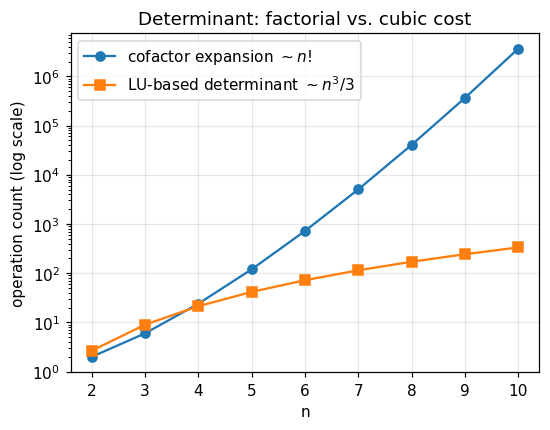

10! = 3628800  vs. 10^3/3 = 333.3333333333333


In [16]:
def det_via_lu(A):
    _, U, perm = lu_pivot(A)
    S = np.sum(perm != np.arange(len(perm)))  # not exact swap count, but parity is what matters below
    # recompute parity properly by counting transpositions of the permutation
    perm = list(perm)
    visited = [False] * len(perm)
    parity = 0
    for i in range(len(perm)):
        if visited[i] or perm[i] == i:
            continue
        j, cycle_len = i, 0
        while not visited[j]:
            visited[j] = True
            j = perm[j]
            cycle_len += 1
        parity += cycle_len - 1
    sign = -1.0 if parity % 2 else 1.0
    return sign * np.prod(np.diag(U))

for n in [3, 5, 8]:
    A = rng.uniform(-1, 1, size=(n, n))
    print(f"n={n}: det via LU = {det_via_lu(A): .6f}, np.linalg.det = {np.linalg.det(A): .6f}")

# cost comparison: LU-based determinant vs. brute-force cofactor expansion
import math
ns = np.arange(2, 11)
cofactor_ops = np.array([math.factorial(n) for n in ns], dtype=float)
lu_ops = ns.astype(float) ** 3 / 3
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.semilogy(ns, cofactor_ops, "o-", label=r"cofactor expansion $\sim n!$")
ax.semilogy(ns, lu_ops, "s-", label=r"LU-based determinant $\sim n^3/3$")
ax.set_xlabel("n"); ax.set_ylabel("operation count (log scale)"); ax.legend()
ax.set_title("Determinant: factorial vs. cubic cost")
plt.show()
print("10! =", math.factorial(10), " vs. 10^3/3 =", 10**3/3)

$10!\approx3.6\times10^6$ against $10^3/3\approx333$: already at $n=10$ the cofactor method is $\sim
10^4$ times more expensive, and the gap grows super-exponentially — the cofactor method is unusable
beyond very small $n$.

### 2.4.3 Inverse

$A^{-1}=[\gamma_1,\dots,\gamma_n]$ where $A\gamma_i=e_i$. With $PA=LU$ already computed, each column
costs two triangular solves ($O(n^2)$), so the whole inverse costs
$$\underbrace{\tfrac13n^3}_{\text{factorize once}} + \underbrace{n\cdot 2\cdot\tfrac12n^2}_{n\text{ triangular solves}} = \tfrac13n^3+n^3=\tfrac43n^3,$$
i.e. **4 times** the cost of solving a single system. Computing the inverse via cofactors/adjugate is
again $O(n!)$ or worse. We now verify the standard warning numerically: even when $A^{-1}$ is available,
using it to solve $Ax=b$ is both slower and less accurate than a direct solve.

In [17]:
def inverse_via_lu(A):
    n = A.shape[0]
    L, U, perm = lu_pivot(A)
    Ainv = np.zeros((n, n))
    I = np.eye(n)
    for i in range(n):
        y = forward_substitution(L, I[perm, i])
        Ainv[:, i] = back_substitution(U, y)
    return Ainv

n = 400
# a deliberately ill-conditioned matrix (prescribed singular values spanning 8 decades)
Q1, _ = np.linalg.qr(rng.standard_normal((n, n)))
Q2, _ = np.linalg.qr(rng.standard_normal((n, n)))
A = Q1 @ np.diag(np.logspace(0, 8, n)) @ Q2.T
x_true = rng.uniform(-1, 1, size=n)
b = A @ x_true  # so the exact solution is known: x_true


def median_time(f, reps=11):
    times = []
    for _ in range(reps):
        t0 = time.perf_counter(); f(); times.append(time.perf_counter() - t0)
    return np.median(times)

t_solve = median_time(lambda: sla.solve(A, b))
t_inv = median_time(lambda: np.linalg.inv(A) @ b)
x_solve = sla.solve(A, b)
x_inv = np.linalg.inv(A) @ b

err_solve = np.linalg.norm(x_solve - x_true) / np.linalg.norm(x_true)
err_inv = np.linalg.norm(x_inv - x_true) / np.linalg.norm(x_true)
print(f"kappa_2(A) = {np.linalg.cond(A):.2e}   (n={n}, median over 11 repetitions)")
print(f"time  solve(A,b)      : {t_solve*1e3:8.3f} ms   forward error ||x-x_true||/||x_true|| = {err_solve:.3e}")
print(f"time  inv(A) @ b      : {t_inv*1e3:8.3f} ms   forward error ||x-x_true||/||x_true|| = {err_inv:.3e}")
print(f"-> inv(A)@b is {t_inv/t_solve:.1f}x slower and {err_inv/err_solve:.1f}x less accurate")

kappa_2(A) = 1.00e+08   (n=400, median over 11 repetitions)
time  solve(A,b)      :    4.184 ms   forward error ||x-x_true||/||x_true|| = 1.308e-09
time  inv(A) @ b      :    7.553 ms   forward error ||x-x_true||/||x_true|| = 2.755e-08
-> inv(A)@b is 1.8x slower and 21.1x less accurate


**Why forward error, not residual, is the right test here.** Both methods will report a tiny residual
$\|Ax-b\|$ regardless of $\kappa(A)$ -- that is exactly what backward stability guarantees, and it is
*not* the same as an accurate $x$. Since $\|x-x_{true}\|/\|x_{true}\|\lesssim\kappa(A)\cdot
\|Ax-b\|/\|b\|$, a small residual on an ill-conditioned problem can still hide a large error in $x$
itself. Comparing against the exact, known $x_{true}$ (constructed here as $b:=Ax_{true}$) is what
correctly exposes the extra rounding error accumulated by first forming $A^{-1}$ and then multiplying.

### 2.4.4 Rank estimation

If, while building $U$ via pivoted elimination, the best available pivot in column $k$ satisfies
$|a^{(k-1)}_{\ell k}|<\text{Tol}$ (a relative tolerance, since exact zeros essentially never occur in
floating point), that column is declared (numerically) dependent on the previous ones and is moved past
the working block; the count $r$ of such columns gives $\operatorname{rank}(A)=n-r$.

In [18]:
def rank_via_lu(A, tol=1e-10):
    A = A.astype(float).copy()
    n = A.shape[0]
    r = 0
    k = 0
    active_cols = n  # columns [0, active_cols) are still being reduced
    while k < active_cols:
        sub = np.abs(A[k:, k:active_cols])
        i_rel, j_rel = np.unravel_index(np.argmax(sub), sub.shape)
        piv = sub[i_rel, j_rel]
        if piv < tol:
            break  # remaining submatrix is numerically zero -> rank = k
        i, j = k + i_rel, k + j_rel
        A[[k, i], :] = A[[i, k], :]
        A[:, [k, j]] = A[:, [k, j]]
        for ii in range(k + 1, n):
            m = A[ii, k] / A[k, k]
            A[ii, k:] -= m * A[k, k:]
        k += 1
    return k

Hilbert5 = sla.hilbert(5)
Tn = tridiag_Tn(6)
print("rank(Hilbert 5x5)         :", rank_via_lu(Hilbert5), " (numpy:", np.linalg.matrix_rank(Hilbert5), ")")
print("rank(T_6, tridiagonal SPD):", rank_via_lu(Tn), " (numpy:", np.linalg.matrix_rank(Tn), ")")

rank_deficient = np.outer(rng.uniform(size=5), rng.uniform(size=3)) @ rng.uniform(size=(3, 5))
print("rank(5x5 built to have rank 3):", rank_via_lu(rank_deficient), " (numpy:", np.linalg.matrix_rank(rank_deficient), ")")

rank(Hilbert 5x5)         : 5  (numpy: 5 )
rank(T_6, tridiagonal SPD): 6  (numpy: 6 )
rank(5x5 built to have rank 3): 1  (numpy: 1 )


<a id="s25"></a>
## 2.5 Iterative methods

Direct methods (§2.2–2.4) modify $A$ and, in exact arithmetic, terminate with the exact solution.
**Iterative methods** instead build a sequence $\{x^{(k)}\}\subset\mathbb{R}^n$ with $x^{(k)}\to x$,
*without ever modifying* $A$ — which, as shown in §2.2.2, is exactly what makes them the tool of choice
for large sparse systems.

**General (preconditioned) scheme.** Choose an invertible matrix $M$ (the *preconditioner*) and iterate
$$M x^{(k+1)} = M x^{(k)} + b - Ax^{(k)} \iff x^{(k+1)} = x^{(k)} + M^{-1}r^{(k)}, \qquad r^{(k)}:=b-Ax^{(k)}.$$
Two competing requirements on $M$: (i) the system with $M$ must be *cheap* to solve; (ii) $M\approx A$,
so that convergence is fast. The extreme choice $M=A$ converges in one step but requires solving the
original system — useless. The art of preconditioning is finding a good compromise.

**Real analysis interlude: this is Banach's fixed-point theorem.** Rearranging,
$$x^{(k+1)} = \underbrace{(I-M^{-1}A)}_{=:B}\,x^{(k)} + \underbrace{M^{-1}b}_{=:c} =: \Phi(x^{(k)}),$$
an **affine map** $\Phi:\mathbb{R}^n\to\mathbb{R}^n$. Since $\mathbb{R}^n$ with any norm is a complete
metric space, Theorem 0.4 applies verbatim: if $\|B\|<1$ for some induced norm, $\Phi$ is a contraction,
it has a unique fixed point $x^\*$ (necessarily the solution of $Ax=b$, since $x=\Phi(x)\iff Ax=b$), and
$\|x^{(k)}-x^\*\|\le\|B\|^k\|x^{(0)}-x^\*\|$ **for every starting guess**. Linear algebra builds $B$;
real analysis is the only reason iterating it is guaranteed to work.

### 2.5.1 Jacobi's method

Split $A=D+E$, $D=\operatorname{diag}(A)$, $E=A-D$. Iterate $Dx^{(k+1)}=b-Ex^{(k)}$, i.e. component-wise
$$x_i^{(k+1)}=\frac{1}{a_{ii}}\Big(b_i-\sum_{j\neq i}a_{ij}x_j^{(k)}\Big).$$
Here $M=D$: trivially invertible if $a_{ii}\neq0\;\forall i$.

**Theorem 2.8.** If $A$ is *strictly diagonally dominant*,
$|a_{ii}|>\sum_{j\neq i}|a_{ij}|\;\forall i$ (Def. 2.9 below), then Jacobi converges for every $x^{(0)}$.

*Proof.* The error $e^{(k)}=x^{(k)}-x$ satisfies $e^{(k+1)}=-D^{-1}Ee^{(k)}$ (subtract $Dx=b-Ex$ from the
iteration). In the $\infty$-norm,
$$\|D^{-1}E\|_\infty=\max_i\frac{1}{|a_{ii}|}\sum_{j\neq i}|a_{ij}|<1$$
by diagonal dominance, so $\|e^{(k)}\|_\infty\le\|D^{-1}E\|_\infty^k\|e^{(0)}\|_\infty\to0$. This is again
an instance of Banach's theorem, with $B=-D^{-1}E$. $\blacksquare$

**Definition 2.9.** $A$ is diagonally dominant if $|a_{ii}|\ge\sum_{j\neq i}|a_{ij}|$ for all $i$;
*strictly* so if the inequality is strict for all $i$. (This is a **sufficient**, not necessary,
condition: matrices that fail it can still make Jacobi converge.)

In [19]:
def jacobi(A, b, x0, tol=1e-10, maxiter=500):
    n = len(b)
    D = np.diag(A)
    x = x0.copy()
    history = [np.linalg.norm(A @ x - b)]
    for k in range(maxiter):
        x_new = (b - (A - np.diag(D)) @ x) / D
        history.append(np.linalg.norm(A @ x_new - b))
        if np.linalg.norm(x_new - x) <= tol * np.linalg.norm(x_new):
            x = x_new
            break
        x = x_new
    return x, np.array(history)

### 2.5.2 Gauss–Seidel

Choose $M=D+L$ where $A=D+L+U$ ($L$ strictly lower, $U$ strictly upper). Component-wise, this uses the
*already updated* values $x_j^{(k+1)}$ for $j<i$:
$$a_{ii}x_i^{(k+1)} = b_i-\sum_{j<i}a_{ij}x_j^{(k+1)}-\sum_{j>i}a_{ij}x_j^{(k)}.$$
This in-place update is why Gauss–Seidel typically converges faster than Jacobi under the same diagonal
dominance hypothesis: newer information propagates immediately within the same sweep.

In [20]:
def gauss_seidel(A, b, x0, tol=1e-10, maxiter=500):
    n = len(b)
    x = x0.copy()
    history = [np.linalg.norm(A @ x - b)]
    for k in range(maxiter):
        x_new = x.copy()
        for i in range(n):
            s = A[i, :i] @ x_new[:i] + A[i, i + 1:] @ x[i + 1:]
            x_new[i] = (b[i] - s) / A[i, i]
        history.append(np.linalg.norm(A @ x_new - b))
        if np.linalg.norm(x_new - x) <= tol * np.linalg.norm(x_new):
            x = x_new
            break
        x = x_new
    return x, np.array(history)

### 2.5.3 Richardson's method

Take $M=\frac1\alpha I$: $x^{(k+1)}=x^{(k)}+\alpha r^{(k)}$. For the error, $e^{(k+1)}=(I-\alpha A)e^{(k)}$.

**Theorem 2.10 (optimal $\alpha$ for SPD $A$).** Let $A$ be SPD with eigenvalues
$0<\lambda_n\le\dots\le\lambda_1$. Then $\|I-\alpha A\|_2=\max_i|1-\alpha\lambda_i|$, minimized at
$$\alpha^\*=\frac{2}{\lambda_1+\lambda_n},\qquad\text{giving}\qquad
\rho:=\|I-\alpha^\*A\|_2=\frac{\lambda_1-\lambda_n}{\lambda_1+\lambda_n}=\frac{\kappa(A)-1}{\kappa(A)+1}<1.$$

*Proof.* $\|I-\alpha A\|_2=\max_i|1-\alpha\lambda_i|$ since $A$ is symmetric (spectral theorem, Fact
0.3). The map $\alpha\mapsto\max(|1-\alpha\lambda_1|,|1-\alpha\lambda_n|)$ (the extreme eigenvalues
dominate) is minimized when the two extremes are balanced in magnitude with opposite sign,
$1-\alpha\lambda_1=-(1-\alpha\lambda_n)$, giving $\alpha^\*=2/(\lambda_1+\lambda_n)$ and the stated
$\rho$. Writing $\kappa=\lambda_1/\lambda_n$ and dividing numerator and denominator by $\lambda_n$ gives
the second formula. $\blacksquare$

This makes explicit the role of the **condition number**: $\kappa(A)\approx1\Rightarrow\rho\approx0$
(fast convergence), $\kappa(A)\gg1\Rightarrow\rho\approx1$ (painfully slow convergence) — precisely the
quantity introduced in Part 0.

In [21]:
def richardson(A, b, x0, alpha, tol=1e-10, maxiter=2000):
    x = x0.copy()
    history = [np.linalg.norm(A @ x - b)]
    for k in range(maxiter):
        r = b - A @ x
        x_new = x + alpha * r
        history.append(np.linalg.norm(A @ x_new - b))
        if np.linalg.norm(x_new - x) <= tol * np.linalg.norm(x_new):
            x = x_new
            break
        x = x_new
    return x, np.array(history)

### 2.5.4 Stopping criteria and convergence-rate estimate

Two practical criteria (a while-loop must stop somehow):

* **Residual test:** stop when $\|Ax^{(k)}-b\|\le C\cdot\text{Tol}$, with $C=\|b\|$ or $C=\|A\|$ (cheap
  norms, $\|\cdot\|_1$ or $\|\cdot\|_\infty$) to make the test relative rather than absolute.
* **Successive-iterate test:** stop when $\|x^{(k+1)}-x^{(k)}\|\le\|x^{(k)}\|\cdot\text{Tol}$.

If $\|e^{(k)}\|\le\rho^k\|e^{(0)}\|$, to gain a further factor $\varepsilon$ of accuracy we need
$$k \ge \frac{\log\varepsilon}{\log\rho}.$$
(**Do not confuse** this *algorithmic tolerance* $\varepsilon$ — chosen by the user — with the *machine
epsilon* $\varepsilon_{mach}$ of Chapter 1, a fixed hardware constant unrelated to how many iterations an
algorithm needs.) For Richardson/SPD with $\rho=(\kappa-1)/(\kappa+1)$ and $\varepsilon=0.1$ (one more
correct decimal digit), a short expansion for $\kappa\gg1$ gives $k\gtrsim\frac{\log10}{2}\kappa(A)$: the
number of iterations needed to gain one digit is *of the same order as the condition number itself*.

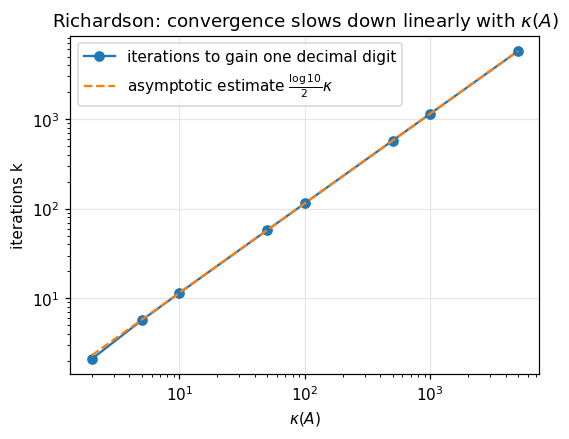

In [22]:
kappas = np.array([2, 5, 10, 50, 100, 500, 1000, 5000])
rho = (kappas - 1) / (kappas + 1)
k_needed = np.log(0.1) / np.log(rho)

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.loglog(kappas, k_needed, "o-", label="iterations to gain one decimal digit")
ax.loglog(kappas, 0.5 * np.log(10) * kappas, "--", label=r"asymptotic estimate $\frac{\log 10}{2}\kappa$")
ax.set_xlabel(r"$\kappa(A)$"); ax.set_ylabel("iterations k"); ax.legend()
ax.set_title("Richardson: convergence slows down linearly with " + r"$\kappa(A)$")
plt.show()

### 2.5.5 Comparing the three methods

We build a random, strictly diagonally dominant matrix (Theorem 2.8 guarantees convergence of both
Jacobi and Gauss–Seidel) and compare all three iterative methods on the same system.

Theorem 2.8 check on a general (non-symmetric) diagonally dominant A:
  Jacobi        :  10 iters, ||x_jac-x_exact||       = 4.63e-13
  Gauss-Seidel  :   8 iters, ||x_gs -x_exact||       = 8.22e-14


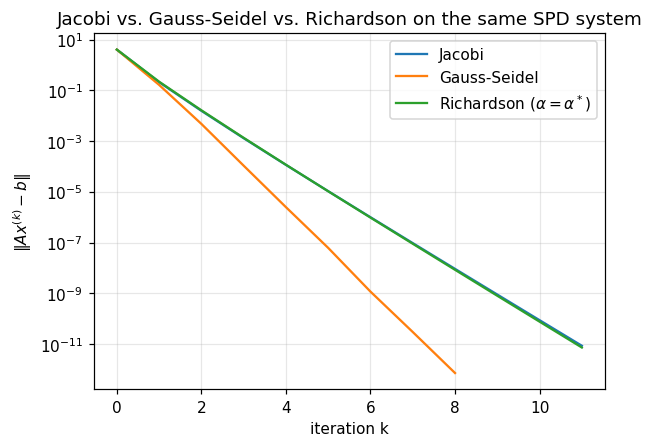

kappa_2(S) = 1.22  ->  optimal Richardson rho = 0.0983


In [23]:
n = 60
A = rng.uniform(-1, 1, size=(n, n))
A += n * np.eye(n)  # forces strict diagonal dominance: |a_ii|=n > sum_j!=i |a_ij| (entries in (-1,1))
b = rng.uniform(-1, 1, size=n)
x_exact = sla.solve(A, b)
x0 = np.zeros(n)

x_jac, hist_jac = jacobi(A, b, x0)
x_gs, hist_gs = gauss_seidel(A, b, x0)
print("Theorem 2.8 check on a general (non-symmetric) diagonally dominant A:")
print(f"  Jacobi        : {len(hist_jac)-1:3d} iters, ||x_jac-x_exact||       = {np.linalg.norm(x_jac-x_exact):.2e}")
print(f"  Gauss-Seidel  : {len(hist_gs)-1:3d} iters, ||x_gs -x_exact||       = {np.linalg.norm(x_gs -x_exact):.2e}")

# For Richardson we need SPD; build a genuinely SPD diagonally dominant matrix instead
S = rng.uniform(-1, 1, size=(n, n))
S = (S + S.T) / 2 + n * np.eye(n)  # SPD, diagonally dominant
b_s = rng.uniform(-1, 1, size=n)
lam = np.linalg.eigvalsh(S)
alpha_star = 2 / (lam[0] + lam[-1])
_, hist_rich = richardson(S, b_s, np.zeros(n), alpha_star)
_, hist_jac_s = jacobi(S, b_s, np.zeros(n))
_, hist_gs_s = gauss_seidel(S, b_s, np.zeros(n))

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.semilogy(hist_jac_s, label="Jacobi")
ax.semilogy(hist_gs_s, label="Gauss-Seidel")
ax.semilogy(hist_rich, label=r"Richardson ($\alpha=\alpha^*$)")
ax.set_xlabel("iteration k"); ax.set_ylabel(r"$\|Ax^{(k)}-b\|$"); ax.legend()
ax.set_title("Jacobi vs. Gauss-Seidel vs. Richardson on the same SPD system")
plt.show()

print(f"kappa_2(S) = {lam[-1]/lam[0]:.2f}  ->  optimal Richardson rho = {(lam[-1]-lam[0])/(lam[-1]+lam[0]):.4f}")

Gauss–Seidel consistently outperforms Jacobi (it uses fresher information within the same sweep), while
Richardson with the theoretically optimal $\alpha^\*$ is competitive but does not exploit the symmetry
of $S$ as effectively as the gradient-type methods of §2.6, built specifically for SPD matrices.

<a id="s26"></a>
## 2.6 Gradient-type methods

From now on $A\in\mathbb{R}^{n\times n}$ is **SPD**: symmetric, and $(x,Ax)>0$ for all $x\neq0$. By Fact
0.3 all eigenvalues of $A$ are real and strictly positive. Symmetry is not an extra requirement bolted
onto SPD — it is already part of the definition.

### 2.6.1 The system is a minimum problem

Define $\varphi:\mathbb{R}^n\to\mathbb{R}$, $\displaystyle \varphi(x)=\tfrac12(x,Ax)-(b,x)$.

**Theorem 2.11.** For $A$ SPD, $x$ solves $Ax=b$ $\iff$ $x=\arg\min_{z\in\mathbb{R}^n}\varphi(z)$.

*Proof ($\Rightarrow$).* $\nabla\varphi(z)=Az-b$ (using symmetry of $A$). If $Ax=b$ then $\nabla\varphi(x)=0$:
$x$ is a critical point. Since $A$ is SPD, the Hessian of $\varphi$ is $A\succ0$, so $\varphi$ is
(strictly) convex, and a critical point of a convex function is its unique global minimum.

*Proof ($\Leftarrow$).* Suppose $x$ minimizes $\varphi$. For any $z\in\mathbb{R}^n$,
$$\varphi(x+z)=\tfrac12(x,Ax)+\tfrac12(z,Az)+(z,Ax)-(b,x)-(b,z)=\varphi(x)+\tfrac12(z,Az)-(z,b-Ax).$$
Since $A$ is SPD, $\tfrac12(z,Az)\ge0$ (with equality only at $z=0$), so
$\varphi(x+z)\ge\varphi(x)-(z,b-Ax)$. If $x$ is a minimizer, $\varphi(x+z)\ge\varphi(x)$ for every $z$,
hence $(z,b-Ax)\ge0$ for every $z$ — including $-z$, forcing $(z,b-Ax)=0\;\forall z$, i.e. $Ax=b$.
$\blacksquare$

This theorem is the hinge of the whole section: it converts **linear algebra** (solve $Ax=b$) into
**real analysis** (minimize a smooth convex functional) — and every method below is simply a different
strategy for descending $\varphi$.

**Remark 2.12 (what goes wrong without SPD).** If $A$ is not symmetric, perturbing $\varphi(x+\alpha z)$
in $\alpha$ shows that its critical point solves $\tfrac12(A+A^T)x=b$, not $Ax=b$, unless $A=A^T$. And
even if $A$ is symmetric but *indefinite* (eigenvalues of both signs), the critical point of $\varphi$ is
a **saddle**, not a minimum — nothing to descend towards. We visualize both the well-posed (SPD) and the
pathological (indefinite) cases below, reproducing the two surfaces from the lecture notes.

A_spd eigenvalues: [1. 3.]  -> SPD: True


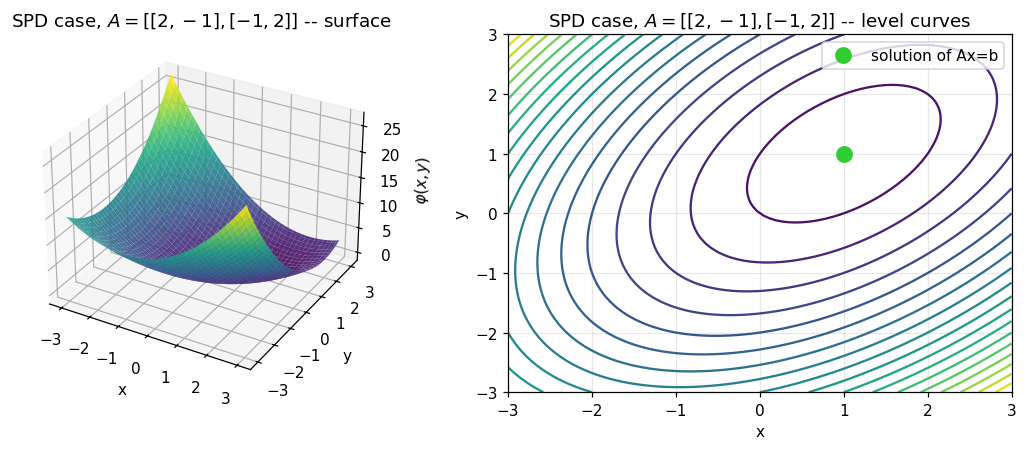

symmetrized saddle-case eigenvalues: [-0.244166  1.104166]  -> indefinite: True


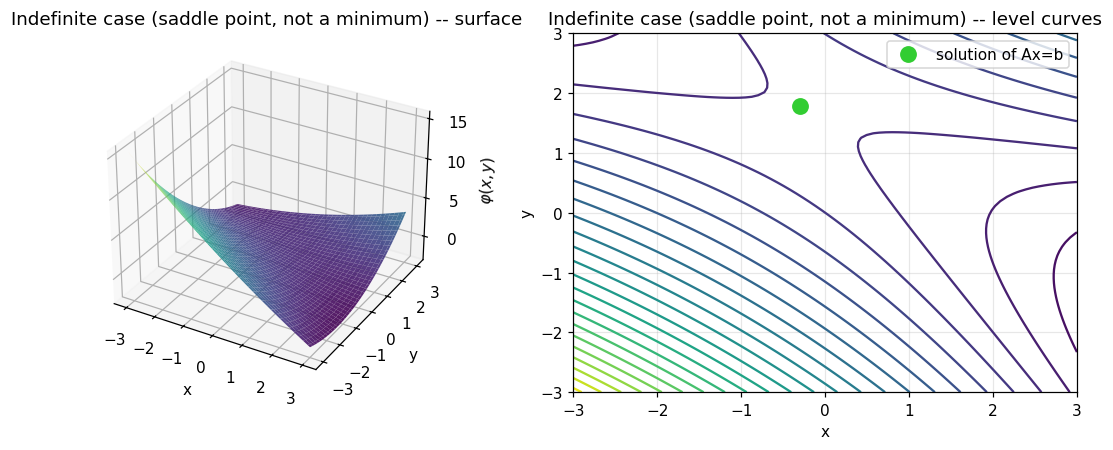

array([-0.298507,  1.791045])

In [24]:
def phi(A, b, X, Y):
    Z = np.zeros_like(X)
    for idx in np.ndindex(X.shape):
        z = np.array([X[idx], Y[idx]])
        Z[idx] = 0.5 * z @ A @ z - b @ z
    return Z

def plot_functional(A, b, title, xr=(-3, 3), yr=(-3, 3)):
    xs = np.linspace(*xr, 80); ys = np.linspace(*yr, 80)
    X, Y = np.meshgrid(xs, ys)
    Z = phi(A, b, X, Y)
    x_star = np.linalg.solve(A, b)

    fig = plt.figure(figsize=(10, 4.2))
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1.plot_surface(X, Y, Z, cmap="viridis", alpha=0.9, linewidth=0)
    ax1.set_title(title + " -- surface")
    ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel(r"$\varphi(x,y)$")

    ax2 = fig.add_subplot(1, 2, 2)
    cs = ax2.contour(X, Y, Z, levels=25, cmap="viridis")
    ax2.plot(x_star[0], x_star[1], "o", color="limegreen", markersize=10, label="solution of Ax=b")
    ax2.set_title(title + " -- level curves"); ax2.legend()
    ax2.set_xlabel("x"); ax2.set_ylabel("y")
    plt.tight_layout(); plt.show()
    return x_star

A_spd = np.array([[2., -1.], [-1., 2.]])
b2 = np.array([1., 1.])
eigvals_spd = np.linalg.eigvalsh(A_spd)
print("A_spd eigenvalues:", eigvals_spd, " -> SPD:", np.all(eigvals_spd > 0))
plot_functional(A_spd, b2, r"SPD case, $A=[[2,-1],[-1,2]]$")

A_saddle = np.array([[0.19, 0.59], [0.67, 0.67]])
eigvals_saddle = np.linalg.eigvalsh((A_saddle + A_saddle.T) / 2)
print("symmetrized saddle-case eigenvalues:", eigvals_saddle, " -> indefinite:", eigvals_saddle[0] * eigvals_saddle[-1] < 0)
plot_functional(A_saddle, b2, "Indefinite case (saddle point, not a minimum)")

The SPD matrix produces a paraboloid with elliptical level curves and a unique minimum, exactly at the
solution of $Ax=b$ (green dot). The indefinite matrix produces a saddle: the critical point still solves
the (symmetrized) linear system, but there is no minimum to descend to — gradient-type methods are
**not applicable** in this regime, which is precisely why every method below assumes $A$ SPD.

### 2.6.2 The residual is the direction of steepest descent -- a Cauchy-Schwarz argument

**Proposition 2.13.** Let $f$ be differentiable at $x$, $\nabla f(x)\neq0$. Among unit vectors $d$, the
directional derivative $D_df(x)=(\nabla f(x),d)$ is minimized (most negative -- fastest local decrease of
$f$) exactly at $d=-\nabla f(x)/\|\nabla f(x)\|$.

*Proof.* By the Cauchy-Schwarz inequality, $(\nabla f(x),d)\ge-\|\nabla f(x)\|\,\|d\|=-\|\nabla f(x)\|$
for every unit vector $d$, with equality iff $d$ is a negative multiple of $\nabla f(x)$ of unit length,
i.e. $d=-\nabla f(x)/\|\nabla f(x)\|$. $\blacksquare$

For $\varphi(x)=\tfrac12(x,Ax)-(b,x)$, $\nabla\varphi(x^{(k)})=Ax^{(k)}-b=-r^{(k)}$ where
$r^{(k)}:=b-Ax^{(k)}$ is the **residual**. Proposition 2.13 says the residual $r^{(k)}$ (not merely "some
uphill-downhill direction") is *the* direction of steepest descent of $\varphi$ at $x^{(k)}$. Every
method in this section takes a step
$$x^{(k+1)}=x^{(k)}+\alpha_k r^{(k)}$$
along that direction; they differ **only** in how $\alpha_k$ is chosen. Richardson (§2.5.3) is the
special case with $\alpha_k\equiv\alpha$ fixed for all $k$ -- "the same step size regardless of where you
are on the surface". The gradient-type methods below instead recompute the optimal step at every
iteration.

In [25]:
def steepest_descent(A, b, x0, tol=1e-10, maxiter=5000, track_path=False):
    '''Method of the Gradient: alpha_k = (r,r)/(r,Ar), minimizes ||e^{k+1}||_A.'''
    x = x0.copy()
    r = b - A @ x
    hist = [np.linalg.norm(r)]
    path = [x.copy()] if track_path else None
    alphas = []
    for k in range(maxiter):
        Ar = A @ r
        alpha = (r @ r) / (r @ Ar)
        x = x + alpha * r
        r = r - alpha * Ar
        hist.append(np.linalg.norm(r))
        alphas.append(alpha)
        if track_path:
            path.append(x.copy())
        if hist[-1] <= tol * hist[0]:
            break
    if track_path:
        return x, np.array(hist), np.array(alphas), np.array(path)
    return x, np.array(hist), np.array(alphas)


def ortomin(A, b, x0, tol=1e-10, maxiter=5000, track_path=False):
    '''Ortomin: alpha_k = (r,Ar)/(Ar,Ar), minimizes ||r^{k+1}||_2. Works even if A is not symmetric,
    as long as (Az,z) != 0 along the iterates.'''
    x = x0.copy()
    r = b - A @ x
    hist = [np.linalg.norm(r)]
    path = [x.copy()] if track_path else None
    alphas = []
    for k in range(maxiter):
        Ar = A @ r
        alpha = (r @ Ar) / (Ar @ Ar)
        x = x + alpha * r
        r = r - alpha * Ar
        hist.append(np.linalg.norm(r))
        alphas.append(alpha)
        if track_path:
            path.append(x.copy())
        if hist[-1] <= tol * hist[0]:
            break
    if track_path:
        return x, np.array(hist), np.array(alphas), np.array(path)
    return x, np.array(hist), np.array(alphas)

> **Common pitfall -- do not confuse the two step-size formulas:**
> $$\text{Ortomin: } \alpha_k=\frac{(r^{(k)},Ar^{(k)})}{(Ar^{(k)},Ar^{(k)})} \qquad\text{vs.}\qquad
> \text{Gradient: } \alpha_k=\frac{(r^{(k)},r^{(k)})}{(r^{(k)},Ar^{(k)})}.$$
> The position of $Ar^{(k)}$ swaps between numerator/denominator role; the two methods minimize
> different quantities (residual norm vs. energy-norm error) and are derived independently below.

**Derivation of the gradient step ($\alpha_k$ minimizes $\|e^{(k+1)}\|_A^2$).** Define the *energy norm*
$\|z\|_A^2:=(z,Az)$ (a genuine norm precisely because $A$ is SPD -- Exercise 2.7.10). With
$e^{(k+1)}=e^{(k)}-\alpha_k r^{(k)}$,
$$g(\alpha):=\|e^{(k+1)}\|_A^2=(e^{(k)},Ae^{(k)})-2\alpha(r^{(k)},Ae^{(k)})+\alpha^2(r^{(k)},Ar^{(k)}).$$
Using symmetry, and $Ae^{(k)}=Ax^{(k)}-Ax=-r^{(k)}$, we get $(r^{(k)},Ae^{(k)})=-(r^{(k)},r^{(k)})$.
Setting $g'(\alpha)=0$:
$$\alpha_k=\frac{(r^{(k)},r^{(k)})}{(r^{(k)},Ar^{(k)})}.$$

**Derivation of the Ortomin step ($\alpha_k$ minimizes $\|r^{(k+1)}\|_2^2$).** From
$r^{(k+1)}=r^{(k)}-\alpha_kAr^{(k)}$,
$$g(\alpha)=(r^{(k)},r^{(k)})-2\alpha(r^{(k)},Ar^{(k)})+\alpha^2(Ar^{(k)},Ar^{(k)}),\quad g'(\alpha)=0
\;\Rightarrow\;\alpha_k=\frac{(r^{(k)},Ar^{(k)})}{(Ar^{(k)},Ar^{(k)})}.$$
Geometrically, $r^{(k+1)}$ lies on the line $\{r^{(k)}-\alpha Ar^{(k)}:\alpha\in\mathbb{R}\}$; minimizing
its norm is an **orthogonal projection** of the origin onto that line, achieved exactly when
$r^{(k+1)}\perp Ar^{(k)}$ -- which is what the formula above enforces. Unlike the gradient method,
Ortomin needs no symmetry of $A$ (only $(Az,z)\neq0$ along the iterates), but it can stall or diverge if
$A$ has eigenvalues of both signs.

In [26]:
# Reproduce the worked example from the lecture notes:
# A = [[2,-1],[-1,2]], b=[1,2], x0=[1/3, 1.641...] -- eigenvalues 1 and 3.
A_ex = np.array([[2., -1.], [-1., 2.]])
b_ex = np.array([1., 2.])
x0_ex = np.array([1 / 3, 1.6410])

x_sd, hist_sd, alphas_sd = steepest_descent(A_ex, b_ex, x0_ex, tol=1e-16, maxiter=12)
print(f"{'iter':>4} | {'residual':>12} | {'alpha_k':>10}")
for k, (r, a) in enumerate(zip(hist_sd[1:], alphas_sd)):
    print(f"{k:4d} | {r:12.5e} | {a:10.5f}")
print("\nexact solution x* =", np.linalg.solve(A_ex, b_ex))
print("computed x        =", x_sd)

iter |     residual |    alpha_k
   0 |  4.92205e-01 |    0.35962
   1 |  2.52249e-01 |    0.82017
   2 |  5.66822e-02 |    0.35962
   3 |  2.90489e-02 |    0.82017
   4 |  6.52750e-03 |    0.35962
   5 |  3.34526e-03 |    0.82017
   6 |  7.51705e-04 |    0.35962
   7 |  3.85239e-04 |    0.82017
   8 |  8.65661e-05 |    0.35962
   9 |  4.43640e-05 |    0.82017
  10 |  9.96892e-06 |    0.35962
  11 |  5.10894e-06 |    0.82017

exact solution x* = [1.333333 1.666667]
computed x        = [1.333331 1.666667]


As in the lecture notes, the steepest-descent step size $\alpha_k$ **oscillates between exactly two
values** (visible above), and the residual decreases geometrically but along a classic **zig-zag** path.
We now visualize this path directly on the level curves of $\varphi$, and contrast a well-conditioned
matrix ($\kappa\approx1$, near-circular contours, no zig-zag) with an ill-conditioned one (elongated
elliptical contours, pronounced zig-zag).

**Choosing a starting point that shows the worst case.** For a $2\times2$ SPD $A$ with eigenpairs
$(\lambda_i,v_i)$, the Kantorovich inequality underlying the per-step bound
$\|e^{(k+1)}\|_A\le\frac{\kappa-1}{\kappa+1}\|e^{(k)}\|_A$ is *tight* exactly when the residual has equal
-magnitude components in the two eigendirections after scaling by the eigenvalues, i.e. when
$e^{(0)}=v_1/\lambda_1+v_2/\lambda_2$ (up to a scalar). Starting elsewhere, steepest descent on a
$2\times2$ system can converge far faster than the bound (it is only a worst-case guarantee), which
would make a "typical" random starting point a misleading illustration. We therefore deliberately place
$x^{(0)}$ at this worst-case alignment, to see the bound realized exactly.

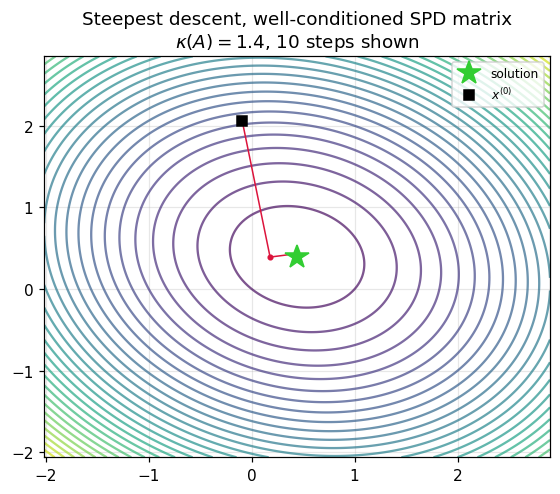

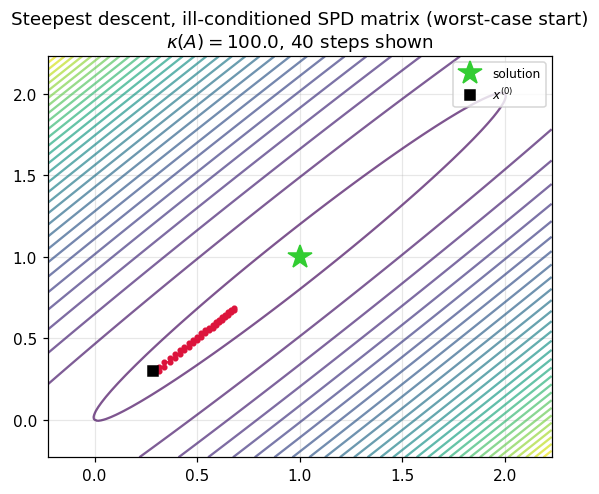

well-conditioned (kappa=1.35): converges in 10 iterations
ill-conditioned  (kappa=100.0): needs 922 iterations for the same tolerance (only the first ~40 zig-zag steps are plotted above)
observed per-step residual ratio: 0.980198  vs.  theoretical (k-1)/(k+1) = 0.980198


In [27]:
def worst_case_x0(A, x_star, scale=1.0):
    '''Error e0 = x0 - x_star aligned so that ||e0||_A contracts at exactly the worst-case rate
    (kappa-1)/(kappa+1) every step -- the classical tightness condition for steepest descent.'''
    w, V = np.linalg.eigh(A)
    return x_star + scale * (V @ (1.0 / w))


def plot_descent_path(A, b, x0, method, title, tol=1e-8, maxiter=60):
    x_star = np.linalg.solve(A, b)
    _, hist, _, path = method(A, b, x0, tol=tol, maxiter=maxiter, track_path=True)
    path = np.array(path)

    margin = 1.3 * np.max(np.abs(path - x_star)) + 0.3
    xs = np.linspace(x_star[0] - margin, x_star[0] + margin, 200)
    ys = np.linspace(x_star[1] - margin, x_star[1] + margin, 200)
    X, Y = np.meshgrid(xs, ys)
    Z = phi(A, b, X, Y)

    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    ax.contour(X, Y, Z, levels=30, cmap="viridis", alpha=0.7)
    ax.plot(path[:, 0], path[:, 1], "o-", color="crimson", markersize=3, linewidth=1)
    ax.plot(x_star[0], x_star[1], "*", color="limegreen", markersize=16, label="solution")
    ax.plot(x0[0], x0[1], "s", color="black", markersize=6, label=r"$x^{(0)}$")
    kappa = np.linalg.cond(A)
    ax.set_title(f"{title}\n" + rf"$\kappa(A)={kappa:.1f}$, {len(path)-1} steps shown")
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()


def iterations_to_converge(A, b, x0, tol=1e-8, maxiter=5000):
    _, hist, _ = steepest_descent(A, b, x0, tol=tol, maxiter=maxiter)
    return len(hist) - 1

# well-conditioned: near-circular level curves
A_good = np.array([[2., 0.3], [0.3, 2.2]])
b_good = np.array([1., 1.])
x_star_good = np.linalg.solve(A_good, b_good)
x0_good = worst_case_x0(A_good, x_star_good, scale=2.5)
plot_descent_path(A_good, b_good, x0_good, steepest_descent,
                   "Steepest descent, well-conditioned SPD matrix", maxiter=30)
n_good = iterations_to_converge(A_good, b_good, x0_good)

# ill-conditioned: rotated, elongated level curves, same worst-case alignment -> persistent zig-zag
theta = np.pi / 4
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
A_bad = R.T @ np.diag([100.0, 1.0]) @ R
b_bad = np.array([1., 1.])
x_star_bad = np.linalg.solve(A_bad, b_bad)
x0_bad = worst_case_x0(A_bad, x_star_bad, scale=1.0)
plot_descent_path(A_bad, b_bad, x0_bad, steepest_descent,
                   "Steepest descent, ill-conditioned SPD matrix (worst-case start)", maxiter=40)
n_bad = iterations_to_converge(A_bad, b_bad, x0_bad)

kappa_good, kappa_bad = np.linalg.cond(A_good), np.linalg.cond(A_bad)
print(f"well-conditioned (kappa={kappa_good:.2f}): converges in {n_good} iterations")
print(f"ill-conditioned  (kappa={kappa_bad:.1f}): needs {n_bad} iterations for the same tolerance "
      f"(only the first ~40 zig-zag steps are plotted above)")

# verify the per-step contraction matches Theorem 2.10's bound *exactly* at this alignment
_, hist_bad, _ = steepest_descent(A_bad, b_bad, x0_bad, tol=1e-12, maxiter=20)
ratio_observed = hist_bad[10] / hist_bad[9]
rho_theory = (kappa_bad - 1) / (kappa_bad + 1)
print(f"observed per-step residual ratio: {ratio_observed:.6f}  vs.  theoretical (k-1)/(k+1) = {rho_theory:.6f}")

The well-conditioned system is essentially solved in a handful of corrective steps; the ill-conditioned
one, started at the theoretical worst-case alignment, needs **two orders of magnitude more iterations**
and its per-step residual reduction matches the bound $\rho=(\kappa-1)/(\kappa+1)$ of Theorem 2.10 to
six decimal digits -- a direct, geometric *and* numerical confirmation that convergence speed is governed
by $\kappa(A)$, visible here as the eccentricity of the level curves themselves.

### 2.6.3 Conjugate gradient: descending in a plane, not on a line

Steepest descent and Ortomin both minimize along the single line $e^{(k)}+\operatorname{span}(r^{(k)})$
(equivalently $\operatorname{span}(p^{(k)})$ with $p^{(k)}:=r^{(k)}$). **Conjugate gradient (CG)**
instead minimizes over the *plane* $e^{(k)}+\operatorname{span}(p^{(k)},p^{(k-1)})$, generated by a new
search direction $p^{(k)}$ built to be $A$-orthogonal to the previous one.

**$A$-orthogonality.** For $A$ SPD, $(x,z)_A:=(x,Az)$ is an inner product; $x,z$ are $A$-orthogonal if
$(x,Az)=0$.

**Step size.** With $x^{(k+1)}=x^{(k)}+\alpha_kp^{(k)}$, requiring $e^{(k+1)}$ to be $A$-orthogonal to
$p^{(k)}$ gives (using symmetry, $Ae^{(k)}=-r^{(k)}$)
$$0=(e^{(k+1)},Ap^{(k)})=(r^{(k)},p^{(k)})-\alpha_k(Ap^{(k)},p^{(k)}) \;\Longrightarrow\;
\alpha_k=\frac{(r^{(k)},p^{(k)})}{(Ap^{(k)},p^{(k)})}.$$
(If $p^{(k)}=r^{(k)}$ this collapses to the plain-gradient formula -- consistent with the remark above.)

**New direction.** Look for $p^{(k)}=r^{(k)}-\beta_kp^{(k-1)}$ such that $e^{(k+1)}$ is *also*
$A$-orthogonal to $p^{(k-1)}$:
$$0=(e^{(k+1)},Ap^{(k-1)})=(r^{(k)},p^{(k-1)})-\alpha_k(p^{(k)},Ap^{(k-1)}),$$
and since $(r^{(k)},p^{(k-1)})=0$ already holds by construction from the previous step, this forces
$(p^{(k)},Ap^{(k-1)})=0$, i.e.
$$\beta_k=\frac{(r^{(k)},Ap^{(k-1)})}{(p^{(k-1)},Ap^{(k-1)})}.$$

**Theorem 2.14 (finite termination).** In exact arithmetic, conjugate gradient reaches the exact
solution in **at most $n$ steps**.

*Proof (sketch).* One shows inductively that not only is $e^{(k+1)}$ $A$-orthogonal to $p^{(k)}$ and
$p^{(k-1)}$, but the *entire* sequence of search directions $p^{(0)},p^{(1)},\dots$ is mutually
$A$-orthogonal. Since $(\cdot,\cdot)_A$ is a genuine inner product on the $n$-dimensional space
$\mathbb{R}^n$, it cannot contain more than $n$ nonzero mutually orthogonal vectors (this is pure linear
algebra: an orthogonal set is linearly independent). Hence $p^{(n)}=0$, forcing $r^{(n)}=0$, i.e.
$e^{(n)}=0$. $\blacksquare$

This is a genuinely different convergence guarantee from Richardson/steepest descent (which only
converge in the limit $k\to\infty$): CG is, in principle, a *direct* method in disguise. In practice
rounding error erodes exact $A$-orthogonality (§2.7, Exercise 6) and CG is used as an iterative method,
typically stopping in $\ll n$ steps once the residual test is satisfied.

In [28]:
def conjugate_gradient(A, b, x0, tol=1e-10, maxiter=None, track_path=False):
    n = len(b)
    maxiter = n if maxiter is None else maxiter
    x = x0.copy()
    r = b - A @ x
    p = r.copy()
    hist = [np.linalg.norm(r)]
    path = [x.copy()] if track_path else None
    for k in range(maxiter):
        Ap = A @ p
        alpha = (r @ p) / (Ap @ p)
        x = x + alpha * p
        r_new = r - alpha * Ap
        hist.append(np.linalg.norm(r_new))
        if track_path:
            path.append(x.copy())
        if hist[-1] <= tol * hist[0]:
            r = r_new
            break
        beta = (r_new @ Ap) / (Ap @ p)
        p = r_new - beta * p
        r = r_new
    if track_path:
        return x, np.array(hist), np.array(path)
    return x, np.array(hist)

In [29]:
n2 = 2
x_cg, hist_cg, path_cg = conjugate_gradient(A_ex, b_ex, x0_ex, tol=1e-14, maxiter=n2, track_path=True)
print("CG on a 2x2 SPD system converges in at most n =", n2, "steps")
print("iterations actually taken:", len(hist_cg) - 1)
print("residual history:", hist_cg)
print("computed x =", x_cg, " exact x* =", np.linalg.solve(A_ex, b_ex))

CG on a 2x2 SPD system converges in at most n = 2 steps
iterations actually taken: 2
residual history: [2.190425 0.492205 0.      ]
computed x = [1.333333 1.666667]  exact x* = [1.333333 1.666667]


### 2.6.4 Comparing the "training" strategies on the same system

We now put every method discussed so far -- Jacobi, Gauss-Seidel, Richardson, steepest descent, Ortomin,
conjugate gradient -- head to head on the tridiagonal SPD matrix $T_n$ from Exercise 2.7.5 (§2.2.2),
sized so it is mildly ill-conditioned.

T_40: SPD tridiagonal, kappa(T) = 680.62


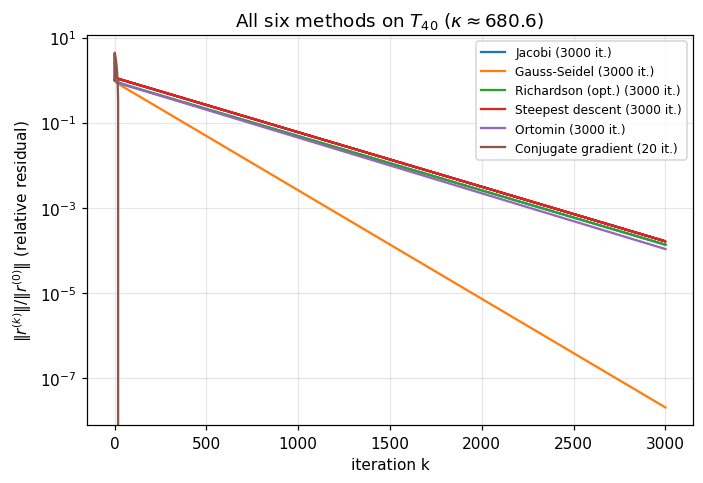

In [30]:
n = 40
T = tridiag_Tn(n)
b_T = np.ones(n)
x0_T = np.zeros(n)
eigT = np.linalg.eigvalsh(T)
kappaT = eigT[-1] / eigT[0]
alpha_star_T = 2 / (eigT[0] + eigT[-1])
print(f"T_{n}: SPD tridiagonal, kappa(T) = {kappaT:.2f}")

_, h_jac = jacobi(T, b_T, x0_T, maxiter=3000)
_, h_gs = gauss_seidel(T, b_T, x0_T, maxiter=3000)
_, h_rich = richardson(T, b_T, x0_T, alpha_star_T, maxiter=3000)
_, h_sd, _ = steepest_descent(T, b_T, x0_T, maxiter=3000)
_, h_om, _ = ortomin(T, b_T, x0_T, maxiter=3000)
_, h_cg = conjugate_gradient(T, b_T, x0_T, maxiter=n)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for hist, label in [(h_jac, "Jacobi"), (h_gs, "Gauss-Seidel"), (h_rich, "Richardson (opt.)"),
                     (h_sd, "Steepest descent"), (h_om, "Ortomin"), (h_cg, "Conjugate gradient")]:
    ax.semilogy(hist / hist[0], label=f"{label} ({len(hist)-1} it.)")
ax.set_xlabel("iteration k"); ax.set_ylabel(r"$\|r^{(k)}\|/\|r^{(0)}\|$ (relative residual)")
ax.set_title(rf"All six methods on $T_{{{n}}}$ ($\kappa\approx{kappaT:.1f}$)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

Conjugate gradient reaches machine precision in far fewer than $n$ iterations; Jacobi, Gauss-Seidel and
Richardson decay geometrically at the rate predicted by $\kappa(T)$; steepest descent and Ortomin sit in
between, still visibly zig-zagging (equal step reductions punctuated by plateaus) compared to CG's
monotone plunge. Note that $T_n$ is only *weakly* diagonally dominant (interior rows have
$|a_{ii}|=2=\sum_{j\neq i}|a_{ij}|$, not strict, so Theorem 2.8 does not literally apply) -- yet Jacobi
still converges, the expected situation for a "sufficient, not necessary" condition.

### 2.6.5 Scaling to a genuinely sparse problem: the 2-D discrete Laplacian

Finally we confirm, on the sparse 2-D Laplacian of §2.2.2 (the library-independent analogue of
`gallery('poisson', m)`), the textbook estimates for the number of iterations to convergence:
$N_{it}=O(n)$ for the plain gradient method and $N_{it}=O(\sqrt n)$ for conjugate gradient, where
$n=m^2$ is the matrix size. Because $A$ is used only through matrix-vector products, `scipy.sparse`
handles it with no modification of `steepest_descent` / `conjugate_gradient`.

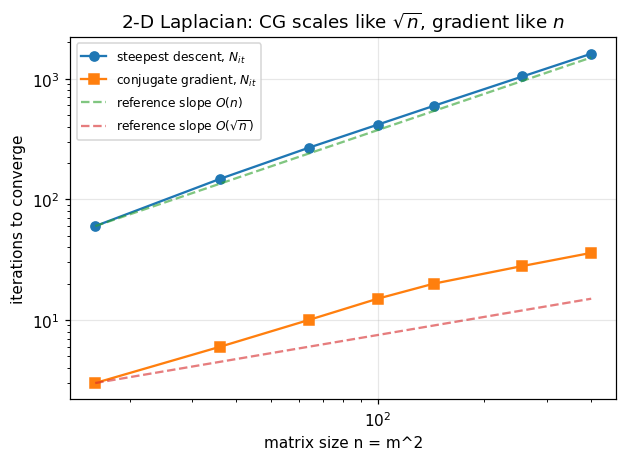

In [31]:
ms = [4, 6, 8, 10, 12, 16, 20]
ns, it_sd, it_cg = [], [], []
for m in ms:
    Lap = laplacian_2d(m)
    n = Lap.shape[0]
    b_L = np.ones(n)
    x0_L = np.zeros(n)
    _, h_sd_L, _ = steepest_descent(Lap, b_L, x0_L, tol=1e-8, maxiter=200000)
    _, h_cg_L = conjugate_gradient(Lap, b_L, x0_L, tol=1e-8, maxiter=n)
    ns.append(n); it_sd.append(len(h_sd_L) - 1); it_cg.append(len(h_cg_L) - 1)

ns = np.array(ns); it_sd = np.array(it_sd); it_cg = np.array(it_cg)

fig, ax = plt.subplots(figsize=(5.8, 4.3))
ax.loglog(ns, it_sd, "o-", label=r"steepest descent, $N_{it}$")
ax.loglog(ns, it_cg, "s-", label=r"conjugate gradient, $N_{it}$")
ax.loglog(ns, it_sd[0] * ns / ns[0], "--", alpha=0.6, label=r"reference slope $O(n)$")
ax.loglog(ns, it_cg[0] * np.sqrt(ns / ns[0]), "--", alpha=0.6, label=r"reference slope $O(\sqrt{n})$")
ax.set_xlabel("matrix size n = m^2"); ax.set_ylabel("iterations to converge")
ax.set_title("2-D Laplacian: CG scales like " + r"$\sqrt{n}$" + ", gradient like " + r"$n$")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

The steepest-descent curve tracks the $O(n)$ reference slope, while conjugate gradient tracks the much
gentler $O(\sqrt n)$ slope -- exactly the qualitative gap between $\rho_{\text{grad}}\sim1-O(1/\kappa)$
and $\rho_{\text{CG}}\sim1-O(1/\sqrt\kappa)$ that distinguishes the two families, and the reason
conjugate gradient (or its preconditioned variants) is the workhorse for large sparse SPD systems in
practice.

<a id="s27"></a>
## 2.7 Exercises

Each exercise is stated, then solved. They are adapted from the course exercise list, extended with the
sparsity/pivoting/geometric themes developed above.

**Exercise 1.** Verify that the hand-written `lu_no_pivot` / `lu_pivot` of §2.3 reproduce `scipy`'s
factorization on a batch of random matrices, and that the residual $\|A-LU\|$ (or $\|PA-LU\|$) scales
with machine epsilon, not with an arbitrary constant.

In [32]:
resids = []
for trial in range(30):
    n = rng.integers(5, 40)
    A = rng.uniform(-1, 1, size=(n, n))
    A += n * np.eye(n)  # keep it well away from singular for this stability check
    L, U, perm = lu_pivot(A)
    resids.append(np.linalg.norm(A[perm, :] - L @ U) / (n * np.finfo(float).eps * np.linalg.norm(A)))
resids = np.array(resids)
print(f"normalized residual ||PA-LU|| / (n*eps*||A||): mean={resids.mean():.3f}, max={resids.max():.3f}")
print("-> consistently O(1): the factorization is backward stable, not merely 'small by luck'.")

normalized residual ||PA-LU|| / (n*eps*||A||): mean=0.036, max=0.079
-> consistently O(1): the factorization is backward stable, not merely 'small by luck'.


**Exercise 2 (Hilbert matrices).** The Hilbert matrix $H_n$, $(H_n)_{ij}=1/(i+j-1)$, is symmetric,
positive definite, and invertible for every $n$, yet notoriously ill-conditioned. Compute the $LU$
factorization residual and $\kappa_2(H_n)$ as functions of $n$.

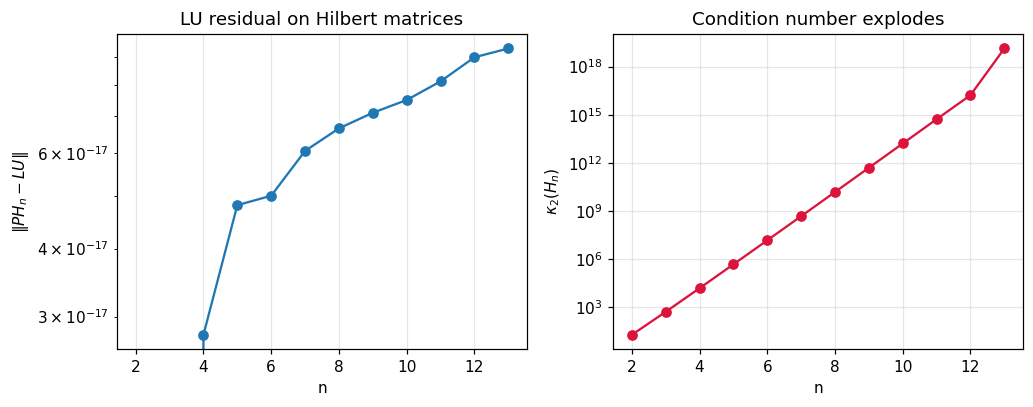

kappa_2(H_13) ~ 1.33e+19  (already far beyond double-precision reliability)


In [33]:
ns_hilbert = np.arange(2, 14)
res_hilbert = []
cond_hilbert = []
for n in ns_hilbert:
    H = sla.hilbert(n)
    L, U, perm = lu_pivot(H)
    res_hilbert.append(np.linalg.norm(H[perm, :] - L @ U))
    cond_hilbert.append(np.linalg.cond(H))

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))
axes[0].semilogy(ns_hilbert, res_hilbert, "o-")
axes[0].set_xlabel("n"); axes[0].set_ylabel(r"$\|PH_n-LU\|$"); axes[0].set_title("LU residual on Hilbert matrices")
axes[1].semilogy(ns_hilbert, cond_hilbert, "o-", color="crimson")
axes[1].set_xlabel("n"); axes[1].set_ylabel(r"$\kappa_2(H_n)$"); axes[1].set_title("Condition number explodes")
plt.tight_layout(); plt.show()
print("kappa_2(H_13) ~ {:.2e}  (already far beyond double-precision reliability)".format(cond_hilbert[-1]))

**Exercise 3 (random vs. Hilbert).** Compare the residual $\|Ax-b\|$ of `solve_gauss_pivot` as a
function of $n$ for (a) random well-scaled matrices and (b) Hilbert matrices.

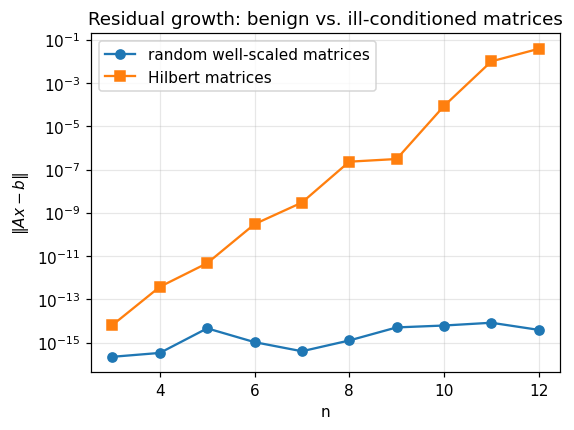

In [34]:
ns_test = np.arange(3, 13)
res_random, res_hilb = [], []
for n in ns_test:
    A_r = rng.uniform(-1, 1, size=(n, n)); b_r = rng.uniform(-1, 1, size=n)
    x_r = solve_gauss_pivot(A_r, b_r)
    res_random.append(np.linalg.norm(A_r @ x_r - b_r))

    H = sla.hilbert(n); b_h = rng.uniform(-1, 1, size=n)
    x_h = solve_gauss_pivot(H, b_h)
    res_hilb.append(np.linalg.norm(H @ x_h - b_h))

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.semilogy(ns_test, res_random, "o-", label="random well-scaled matrices")
ax.semilogy(ns_test, res_hilb, "s-", label="Hilbert matrices")
ax.set_xlabel("n"); ax.set_ylabel(r"$\|Ax-b\|$"); ax.legend()
ax.set_title("Residual growth: benign vs. ill-conditioned matrices")
plt.show()

**Exercise 4 (the inverse of a sparse matrix need not be sparse).** $T_n$ (§2.2.2) is tridiagonal
(sparse). Is $T_n^{-1}$ also sparse?

nonzeros in T_n     : 22 / 64 entries
nonzeros in T_n^-1  : 64 / 64 entries


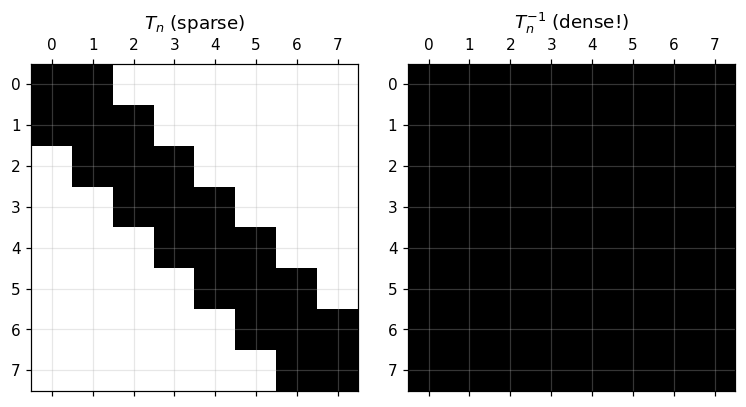

In [35]:
n = 8
Tn = tridiag_Tn(n)
Tn_inv = np.linalg.inv(Tn)
print("nonzeros in T_n     :", np.count_nonzero(Tn), f"/ {n*n} entries")
print("nonzeros in T_n^-1  :", np.count_nonzero(np.abs(Tn_inv) > 1e-12), f"/ {n*n} entries")

fig, axes = plt.subplots(1, 2, figsize=(7, 3.6))
axes[0].spy(Tn); axes[0].set_title(r"$T_n$ (sparse)")
axes[1].spy(np.abs(Tn_inv) > 1e-12); axes[1].set_title(r"$T_n^{-1}$ (dense!)")
plt.tight_layout(); plt.show()

$T_n^{-1}$ is **completely dense**, even though $T_n$ itself is tridiagonal. This is the sharpest
possible illustration of the warning in §2.1/§2.4.3: never form $A^{-1}$ to exploit sparsity -- the
inverse of a sparse matrix is generically dense, so all the memory savings of sparse storage are lost
the moment you invert. Solve $Tx=b$ directly (ideally with the specialized algorithm below) instead.

**Exercise 5 (exploiting tridiagonal structure: the Thomas algorithm).** Write a Gaussian-elimination
variant specialized to a tridiagonal system, and measure its cost against the generic $O(n^3)$
algorithm.

In [36]:
def thomas_algorithm(a, d, c, b):
    '''Solve a tridiagonal system with sub-diagonal a (length n-1), diagonal d (length n),
    super-diagonal c (length n-1), right-hand side b (length n). O(n) cost: no fill-in ever occurs.'''
    n = len(d)
    d, b = d.copy(), b.copy()
    for i in range(1, n):
        m = a[i - 1] / d[i - 1]
        d[i] -= m * c[i - 1]
        b[i] -= m * b[i - 1]
    x = np.zeros(n)
    x[-1] = b[-1] / d[-1]
    for i in range(n - 2, -1, -1):
        x[i] = (b[i] - c[i] * x[i + 1]) / d[i]
    return x

n = 800
a = -np.ones(n - 1); d = 2 * np.ones(n); c = -np.ones(n - 1)
Tn_big = tridiag_Tn(n)
b = rng.uniform(-1, 1, size=n)

t0 = time.perf_counter(); x_thomas = thomas_algorithm(a, d, c, b); t_thomas = time.perf_counter() - t0
t0 = time.perf_counter(); x_generic = solve_gauss_pivot(Tn_big, b); t_generic = time.perf_counter() - t0

print(f"Thomas algorithm : {t_thomas*1e3:8.3f} ms   residual = {np.linalg.norm(Tn_big@x_thomas-b):.2e}")
print(f"generic Gauss    : {t_generic*1e3:8.3f} ms   residual = {np.linalg.norm(Tn_big@x_generic-b):.2e}")
print(f"speed-up: {t_generic/t_thomas:.1f}x for n={n} (grows like n^2 as n increases: O(n) vs O(n^3))")

Thomas algorithm :    1.316 ms   residual = 8.98e-13
generic Gauss    : 1711.377 ms   residual = 8.98e-13
speed-up: 1300.0x for n=800 (grows like n^2 as n increases: O(n) vs O(n^3))


**Exercise 6 (loss of $A$-orthogonality in finite precision).** Theorem 2.14 guarantees the CG search
directions are mutually $A$-orthogonal *in exact arithmetic*. Measure how badly this fails numerically
for a moderately ill-conditioned SPD matrix, by recording all directions $p^{(k)}$ and inspecting the
Gram matrix $G_{jk}=(p^{(j)},Ap^{(k)})$.

well-conditioned $T_{50}$          : kappa_2 = 1.053e+03, max |off-diagonal A-inner product| = 0.000e+00
ill-conditioned Hilbert $H_{50}$   : kappa_2 = 1.378e+19, max |off-diagonal A-inner product| = 2.167e+01


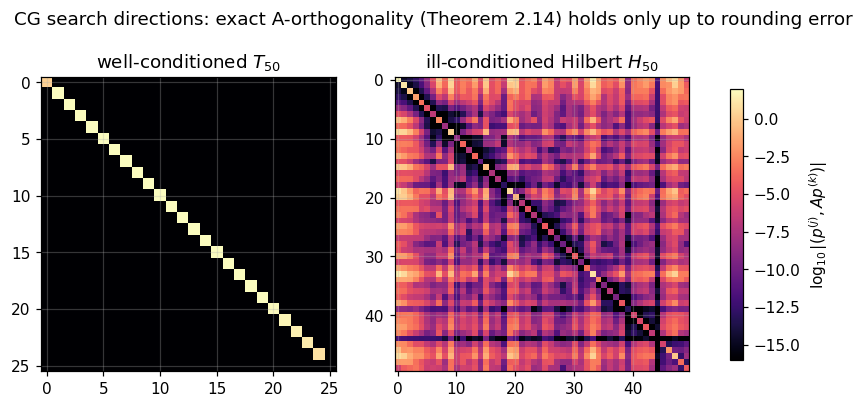

In [37]:
def conjugate_gradient_directions(A, b, x0, maxiter, tol=1e-13):
    '''Records the CG search directions p^(k); stops early (rather than dividing by ~0) once the
    residual has already collapsed to rounding-error level -- exact finite termination (Theorem 2.14)
    on a well-conditioned matrix can happen well before `maxiter` steps.'''
    x = x0.copy(); r = b - A @ x; p = r.copy()
    r0_norm = np.linalg.norm(r)
    P = [p.copy()]
    for k in range(maxiter):
        if np.linalg.norm(r) <= tol * r0_norm:
            break
        Ap = A @ p
        alpha = (r @ p) / (Ap @ p)
        x = x + alpha * p
        r_new = r - alpha * Ap
        beta = (r_new @ Ap) / (Ap @ p)
        p = r_new - beta * p
        P.append(p.copy())
        r = r_new
    return np.array(P)

n = 50
T_wellcond = tridiag_Tn(n)     # well-conditioned SPD matrix (kappa = O(n^2), but tiny compared to Hilbert)
H_illcond = sla.hilbert(n)     # deliberately extreme SPD matrix

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
for ax, A_test, label in [(axes[0], T_wellcond, "well-conditioned " + r"$T_{50}$"),
                           (axes[1], H_illcond, "ill-conditioned Hilbert " + r"$H_{50}$")]:
    b_test = np.ones(n)
    P = conjugate_gradient_directions(A_test, b_test, np.zeros(n), maxiter=n - 1)
    G = P @ A_test @ P.T
    off_diag = G - np.diag(np.diag(G))
    print(f"{label:35s}: kappa_2 = {np.linalg.cond(A_test):.3e}, "
          f"max |off-diagonal A-inner product| = {np.max(np.abs(off_diag)):.3e}")
    im = ax.imshow(np.log10(np.abs(G) + 1e-300), cmap="magma", vmin=-16, vmax=2)
    ax.set_title(label)
plt.colorbar(im, ax=axes, shrink=0.8, label=r"$\log_{10}|(p^{(j)},Ap^{(k)})|$")
plt.suptitle("CG search directions: exact A-orthogonality (Theorem 2.14) holds only up to rounding error")
plt.show()

On a well-conditioned matrix the Gram matrix stays essentially diagonal; on the (deliberately extreme)
Hilbert matrix, rounding error visibly leaks into the off-diagonal entries as $k$ grows -- the practical
reason production CG implementations restart or reorthogonalize periodically on hard problems.

**Exercise 7 (rank estimation).** Apply `rank_via_lu` (§2.4.4) to $T_n$ and to a deliberately
rank-deficient matrix built as a low-rank product, and compare with `np.linalg.matrix_rank`.

In [38]:
for label, M in [("T_10 (full rank)", tridiag_Tn(10)),
                  ("rank-3 product (7x7)", rng.uniform(size=(7, 3)) @ rng.uniform(size=(3, 7)))]:
    print(f"{label:24s}: rank_via_lu = {rank_via_lu(M)}, numpy = {np.linalg.matrix_rank(M)}")

T_10 (full rank)        : rank_via_lu = 10, numpy = 10
rank-3 product (7x7)    : rank_via_lu = 3, numpy = 3


<a id="summary"></a>
## Summary table

| Method | Family | Requires on $A$ | Iteration / preconditioner | Cost per step | Convergence condition | Typical rate | Best suited for |
|---|---|---|---|---|---|---|---|
| Forward / back substitution | Direct | triangular, $a_{ii}\neq0$ | -- | $O(n^2)$ | always (finite algorithm) | exact in 1 pass | solving after any factorization |
| Gauss elimination | Direct | invertible | $M_k$, elementary | $O(n^3/3)$ total | always if pivots $\neq0$ | exact in 1 pass | single solve, small/moderate dense $n$ |
| Gauss with partial pivoting | Direct | invertible | row swaps $+M_k$ | $O(n^3/3)+O(n^2)$ | always ($A$ invertible) | exact, backward stable | default choice for dense systems |
| $LU$ (with $PA=LU$) | Direct | invertible | -- | $O(n^3/3)$ once | always if pivots $\neq0$ | exact | many right-hand sides, det, inverse, rank |
| Jacobi | Iterative | $a_{ii}\neq0$ (diag. dom. sufficient) | $M=D$ | $O(\mathrm{nnz})$ | $\|D^{-1}E\|<1$ | linear, slow | quick baseline, trivially parallel |
| Gauss-Seidel | Iterative | diag. dom. sufficient | $M=D+L$ | $O(\mathrm{nnz})$ | $\|B_{GS}\|<1$ | linear, faster than Jacobi | sparse, sequential updates OK |
| Richardson (optimal $\alpha$) | Iterative | SPD (for optimal $\alpha$) | $M=\tfrac1\alpha I$ | $O(\mathrm{nnz})$ | $0<\alpha<2/\lambda_1$ | $\rho=\frac{\kappa-1}{\kappa+1}$ | simple baseline, tunable |
| Steepest descent (gradient) | Gradient-type | SPD | $\alpha_k=(r,r)/(r,Ar)$ | $O(\mathrm{nnz})$ | $A$ SPD | comparable to Richardson, zig-zag | pedagogical baseline |
| Ortomin | Gradient-type | $(Az,z)\neq0$ | $\alpha_k=(r,Ar)/(Ar,Ar)$ | $O(\mathrm{nnz})$ | $(Az,z)\neq0$ along iterates | minimizes $\|r\|_2$ each step | non-symmetric-tolerant residual minimization |
| Conjugate gradient | Gradient-type | SPD | $A$-orthogonal $p^{(k)}$ | $O(\mathrm{nnz})$ | SPD (exact in $\le n$ steps) | $O(\sqrt\kappa)$ vs $O(\kappa)$ | large sparse SPD systems (the workhorse) |

**Cross-cutting lessons from this chapter.**

* *Pivoting* is asymptotically free ($O(n^2)$ overhead against an $O(n^3)$ algorithm) and removes both a
  hard failure mode (zero pivot) and a soft one (catastrophic error amplification) -- always use it.
* *Sparsity* is a structural property, not just a nonzero count: whether a direct method preserves it
  (fill-in) depends on the matrix's graph, which is exactly why sparse, large-scale problems are the
  natural habitat of iterative and gradient-type methods.
* *Convergence speed of every iterative/gradient method in this chapter is governed by $\kappa(A)$*,
  whether stated algebraically (spectral radius of the iteration matrix) or seen geometrically (the
  eccentricity of the level curves of $\varphi$).
* Two disciplines are doing the actual work throughout: **linear algebra** supplies the objects (matrices,
  eigenvalues, orthogonality), while **real analysis** supplies the *guarantees* (Riemann sums for
  operation counts, Cauchy-Schwarz for the steepest-descent direction, convexity for the minimization
  equivalence, and the Banach fixed-point theorem for every "simple" iterative method).